# <h1 align="center">ADY201 — Final Project</h1>
## <h2 align="center">Python ML — Machine Learning: Dự đoán đặt lại sản phẩm (Reorder Prediction)</h2>

<div align="center">

**Dataset:** Instacart Market Basket Analysis (Kaggle)  
**Tools:** Python &nbsp;|&nbsp; Scikit-learn &nbsp;|&nbsp; XGBoost &nbsp;|&nbsp; SQL Server  
**Đầu vào:** VIEW `feature_table` (SQL Server)  
**Bài toán:** Phân loại nhị phân — dự đoán `reordered` (1 = đặt lại, 0 = không đặt lại)

</div>

---
## Table of Contents

1. [Library Setup](#c-setup)
2. [Database Connection](#c-connect)
3. [I. Phân khúc khách hàng — K-Means (RFM)](#section-I)
4. [II. Kiểm định đặc trưng (Feature Audit)](#section-II)
5. [III. Kiểm tra cân bằng nhãn](#section-III)
6. [IV. Chia tập Train/Test](#section-IV)
7. [V. Logistic Regression (GridSearchCV)](#section-V)
8. [VI. XGBoost (GridSearchCV)](#section-VI)
9. [VII. Learning Curve — kiểm tra Overfitting](#section-VII)
10. [VIII. Confusion Matrix & Classification Report](#section-VIII)
11. [IX. Bảng dự đoán mẫu](#section-IX)
12. [X. ROC Curve](#section-X)
13. [XI. Bootstrap — kiểm định ý nghĩa thống kê AUC](#section-XI)
14. [XII. Precision-Recall Curve & Threshold](#section-XII)
15. [XIII. Feature Importance](#section-XIII)
16. [XIV. Xuất kết quả](#section-XIV)
17. [Python ML Summary](#c-summary)

---
## 1. Library Setup <a id="c-setup"></a>

**Prerequisites:**
- Python Data Processing đã hoàn thành — dữ liệu đã nạp vào SQL Server.
- SQL đã tạo VIEW `feature_table` (xem `plan_sql_v2.md` — Phần 4 / `ADY201_Report.docx` — mục 5.2).

| Thư viện | Mục đích |
|---|---|
| `pandas`, `numpy` | Đọc và xử lý dữ liệu |
| `matplotlib`, `seaborn` | Vẽ biểu đồ đánh giá mô hình |
| `sqlalchemy` | Kết nối SQL Server |
| `scikit-learn` | Train/test split, Pipeline, GridSearchCV, các chỉ số đánh giá |
| `xgboost` | Mô hình XGBoost |

> **Lưu ý về thời gian chạy:** GridSearchCV chạy nhiều tổ hợp tham số × nhiều fold — có thể mất từ vài phút (Logistic Regression) đến vài chục phút (XGBoost) tùy cấu hình máy.

---

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
import os, warnings, time
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay,
    precision_recall_curve, PrecisionRecallDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

os.makedirs("output/charts", exist_ok=True)

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 150,
})

# Nhãn viết tắt cho trục biểu đồ (tên gốc quá dài)
FEAT_LABELS = {
    "user_total_orders":            "usr_total_orders",
    "user_avg_days_between_orders": "usr_avg_days",
    "user_reorder_ratio":           "usr_reorder_ratio",
    "product_reorder_rate":         "prod_reorder_rate",
    "avg_add_to_cart_position":     "avg_cart_pos",
    "user_product_times_bought":    "usr_prod_bought",
}

print("Libraries imported successfully.")

Libraries imported successfully.


---
## 2. Database Connection <a id="c-connect"></a>

Đọc trực tiếp từ VIEW `feature_table` và `vw_rfm` đã được SQL Server tổng hợp sẵn (xem Phần III báo cáo / `plan_sql_v2.md` — Phần 4).

**Chỉnh `DATABASE`** nếu tên khác trên máy của bạn.

---

In [2]:
SERVER   = "."
DATABASE = "Project_ADY201m"
USERNAME = "ADY201m-Project"
PASSWORD = "123"

connection_url = (
    f"mssql+pyodbc://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}"
    f"?driver=ODBC+Driver+17+for+SQL+Server&Encrypt=no"
)
engine = create_engine(connection_url, fast_executemany=True)

with engine.connect() as conn:
    db = conn.execute(text("SELECT DB_NAME()")).scalar()
    print(f"Connected to: [{db}]")

with engine.connect() as conn:
    found = conn.execute(text("SELECT name FROM sys.views WHERE name IN ('feature_table','vw_rfm')")).fetchall()
    print(f"VIEWs found: {len(found)}/2")
    for v in found:
        print(f"  {v[0]}")

Connected to: [Project_ADY201m]
VIEWs found: 2/2
  feature_table
  vw_rfm


---
## I. Phân khúc khách hàng — K-Means (RFM) <a id="section-I"></a>

**Business question:** Toàn bộ khách hàng có thể được chia thành bao nhiêu nhóm hành vi mua sắm khác nhau? Đặc điểm của từng nhóm là gì?

| | |
|---|---|
| **Nguồn dữ liệu** | SQL Server — đọc trực tiếp qua `pd.read_sql()` (CTE tính RFM) |
| **Đầu ra file** | `rfm_clustered.csv` — giao Power BI |
| **Quy trình** | SQL → StandardScaler → Elbow method → KMeans → Cluster Heatmap → Export |

**Tại sao không cần VIEW riêng cho K-Means:**  
SQL đã tổng hợp sẵn 3 chỉ số RFM qua CTE. Python đọc thẳng kết quả vào DataFrame, không cần tạo VIEW hay chờ xuất file CSV trung gian — tiết kiệm thời gian và bộ nhớ disk.

**Ba chỉ số RFM:**

| Chỉ số | Ý nghĩa | Cách tính |
|---|---|---|
| **Recency** | Khách mua gần đây không? | `days_since_prior_order` của đơn mới nhất mỗi user |
| **Frequency** | Khách mua thường xuyên không? | Tổng số đơn hàng của user |
| **Monetary** | Khách mua nhiều không? | Tổng sản phẩm đã mua (thay thế giá vì dataset không có cột giá) |

---

### Bước 1 — Đọc dữ liệu RFM trực tiếp từ SQL Server

Thay vì chờ file `rfm_table.csv`, Python đọc thẳng qua `pd.read_sql()` với cùng CTE được dùng để xuất CSV cho Power BI.  
Kết quả trả về là một DataFrame 206,209 dòng (1 dòng = 1 user).

> **Lưu ý:** Query dùng `ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...)` — đây là Window Function, SQL Server thực thi hoàn toàn phía server trước khi trả kết quả về Python.

In [3]:
rfm = pd.read_sql("SELECT * FROM vw_rfm", engine)

print(f"\nSo nguoi dung: {len(rfm):,}")
print(f"So cot       : {rfm.shape[1]}")
print("\nThong ke mo ta:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))


So nguoi dung: 206,209
So cot       : 4

Thong ke mo ta:
         recency  frequency   monetary
count  206209.00  206209.00  206209.00
mean       17.06      16.59     157.29
std        10.67      16.65     204.21
min         0.00       4.00       3.00
25%         7.00       6.00      39.00
50%        15.00      10.00      83.00
75%        30.00      20.00     188.00
max        30.00     100.00    3725.00


### Bước 2 — Chuẩn hóa dữ liệu và tìm số cụm tối ưu (Elbow Method)

**Tại sao phải chuẩn hóa (StandardScaler)?**  
Ba chỉ số RFM có đơn vị và thang đo khác nhau hoàn toàn — `recency` tối đa 30 ngày, `monetary` có thể lên đến hàng trăm sản phẩm. Nếu không chuẩn hóa, K-Means sẽ bị lệch về phía chiều có giá trị lớn hơn.

**Elbow Method:**  
Chạy K-Means với k từ 2 đến 10, vẽ đường cong Inertia (tổng bình phương khoảng cách các điểm đến tâm cụm). Điểm "khuỷu tay" — nơi đường cong bắt đầu giảm chậm lại — là k tối ưu.

Chuẩn hóa hoàn tất — mean~0, std~1 cho cả 3 chiều.
  k= 2 → inertia = 340,051
  k= 3 → inertia = 191,907
  k= 4 → inertia = 141,832
  k= 5 → inertia = 123,199
  k= 6 → inertia = 106,979
  k= 7 → inertia = 93,591
  k= 8 → inertia = 82,748
  k= 9 → inertia = 74,431
  k=10 → inertia = 68,765


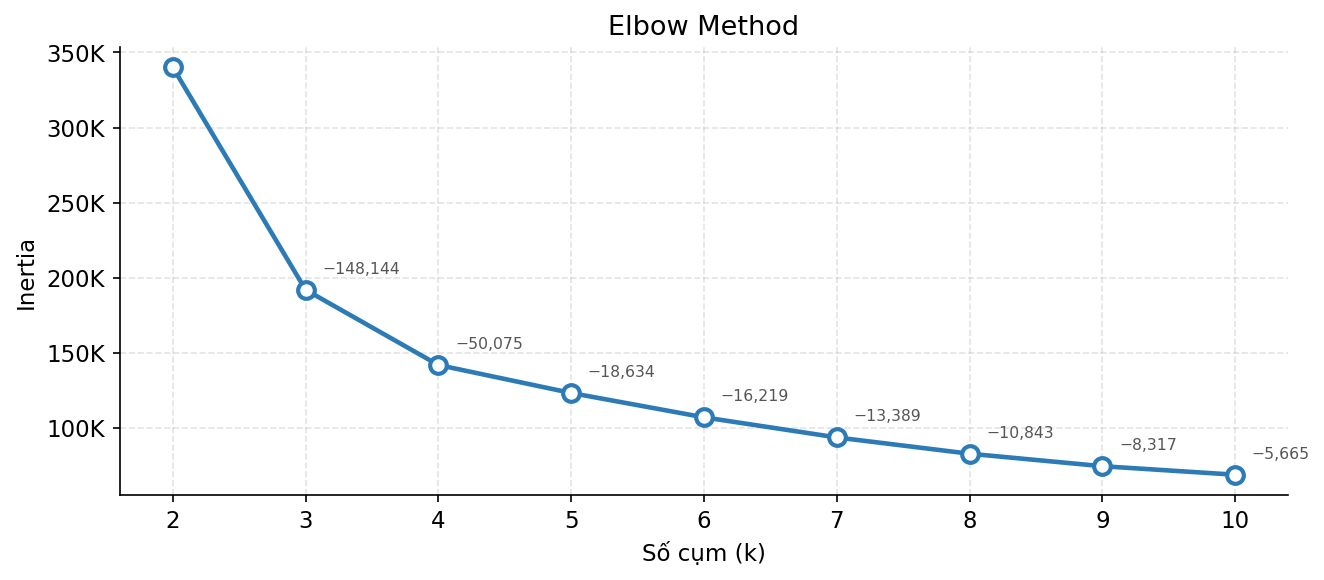

In [4]:
RFM_COLS = ['recency', 'frequency', 'monetary']

# --- Chuẩn hóa về cùng thang đo ---
scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[RFM_COLS])
print("Chuẩn hóa hoàn tất — mean~0, std~1 cho cả 3 chiều.")

# --- Elbow Method ---
inertias = []
K_RANGE  = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    print(f"  k={k:2d} → inertia = {km.inertia_:,.0f}")

# --- Vẽ Elbow ---
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(list(K_RANGE), inertias,
        'o-', color='#2c7bb6', linewidth=2.2, markersize=8,
        markerfacecolor='white', markeredgewidth=2)

# Đánh dấu delta giảm để dễ nhìn điểm gãy
for i in range(1, len(inertias)):
    drop = inertias[i-1] - inertias[i]
    ax.annotate(f"−{drop:,.0f}",
                xy=(list(K_RANGE)[i], inertias[i]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=7.5, color='#555')

ax.set_xlabel('Số cụm (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method', fontsize=13)
ax.set_xticks(list(K_RANGE))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('output/charts/B6a_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

> **Cách đọc biểu đồ Elbow:** Tìm điểm mà mức giảm Inertia (số ghi cạnh mỗi điểm) đột ngột thu nhỏ lại. Đó là k tối ưu — thêm cụm sau điểm này không cải thiện đáng kể chất lượng phân cụm.
>
> Sau khi quan sát biểu đồ, điều chỉnh `K_OPTIMAL` ở cell tiếp theo nếu cần.

### Bước 3 — Huấn luyện K-Means và xem thống kê từng cụm

In [5]:
# ── Điều chỉnh K_OPTIMAL sau khi xem biểu đồ Elbow ──────────────
K_OPTIMAL = 4
# ─────────────────────────────────────────────────────────────────

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# --- Thống kê từng cụm ---
summary = rfm.groupby('cluster')[RFM_COLS].mean().round(2)
summary.insert(0, 'count', rfm.groupby('cluster')['user_id'].count())
summary.insert(1, 'pct_%', (summary['count'] / len(rfm) * 100).round(1))

print(f"K-Means hoàn tất (k={K_OPTIMAL}, n_init=10, random_state=42)")
print(f"Tổng người dùng: {len(rfm):,}")
print("\n── Thống kê trung bình từng cụm ──")
print(summary.to_string())

K-Means hoàn tất (k=4, n_init=10, random_state=42)
Tổng người dùng: 206,209

── Thống kê trung bình từng cụm ──
         count  pct_%  recency  frequency  monetary
cluster                                            
0        30469   14.8     9.41      35.88    356.75
1        78243   37.9     8.86      11.01     88.75
2         9017    4.4     5.59      69.78    840.43
3        88480   42.9    28.12       9.46     79.59


### Bước 4 — Trực quan hóa hồ sơ từng cụm bằng Heatmap

**Tại sao dùng Heatmap thay vì PCA scatter?**  
PCA scatter chỉ cho thấy các cụm tách biệt nhau trên không gian rút gọn 2 chiều, nhưng không trả lời trực tiếp câu hỏi kinh doanh quan trọng hơn: từng cụm mạnh hay yếu ở chỉ số RFM nào. Heatmap hồ sơ cụm (Cluster Profile) quy đổi cả 3 chỉ số Recency, Frequency, Monetary về cùng thang điểm 0–1 theo rank (không dùng min-max vì dễ bị lệch bởi cụm ngoại lai), giúp so sánh trực tiếp mức độ tốt tương đối giữa các cụm — dễ đọc và ra quyết định kinh doanh hơn nhiều so với việc chỉ nhìn các chấm màu trên biểu đồ 2D.

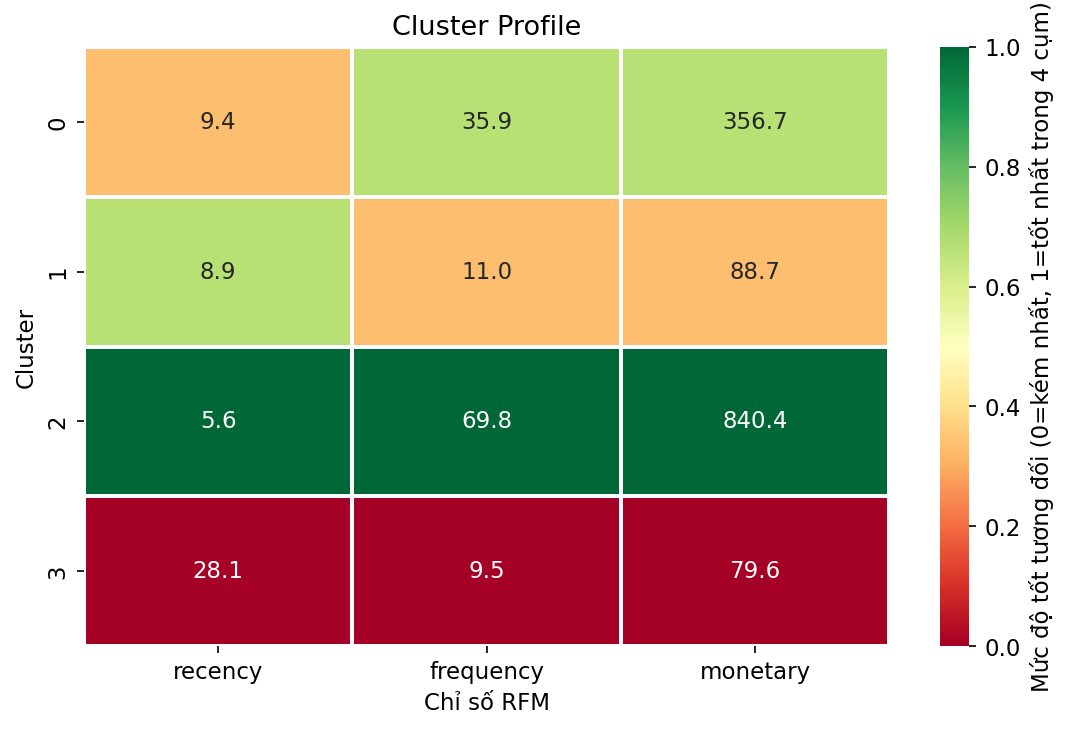

In [6]:
profile = rfm.groupby('cluster')[RFM_COLS].mean()
n = len(profile)

# Hướng "tốt" của từng chỉ số kinh doanh:
# - recency  : THẤP là tốt (mới mua gần đây)
# - frequency: CAO là tốt (mua thường xuyên)
# - monetary : CAO là tốt (mua nhiều)
GOOD_DIRECTION = {'recency': 'low', 'frequency': 'high', 'monetary': 'high'}

score = pd.DataFrame(index=profile.index, columns=RFM_COLS, dtype=float)
for col in RFM_COLS:
    r = profile[col].rank(ascending=True)       # rank 1 = giá trị nhỏ nhất
    if GOOD_DIRECTION[col] == 'low':
        score[col] = (n - r) / (n - 1)           # nhỏ nhất -> score 1 (tốt nhất)
    else:
        score[col] = (r - 1) / (n - 1)           # lớn nhất -> score 1 (tốt nhất)

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.heatmap(
    score, annot=profile.round(1), fmt='.1f',
    cmap='RdYlGn', vmin=0, vmax=1,                # KHÔNG dùng _r -> xanh tự nhiên = tốt
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Mức độ tốt tương đối (0=kém nhất, 1=tốt nhất trong 4 cụm)'},
    ax=ax
)
ax.set_xlabel('Chỉ số RFM')
ax.set_ylabel('Cluster')
ax.set_title('Cluster Profile', fontsize=13)
plt.tight_layout()
plt.savefig('output/charts/B6b_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---

**Phân tích biểu đồ Cluster Profile:**

Sau khi quy đổi 3 chỉ số RFM về cùng một thang điểm "mức độ tốt tương đối" (đảo hướng riêng cho `recency` vì giá trị thấp mới là tích cực), biểu đồ heatmap cho thấy sự phân tách rất rõ ràng giữa 4 cụm khách hàng — khác biệt với hình ảnh mờ nhạt ở các lần thử trước với PCA scatter.

- **Cluster 1** đạt điểm tốt nhất ở **cả 3 chỉ số** (recency thấp nhất = 5.6 ngày, frequency cao nhất = 69.5 đơn, monetary cao nhất = 837.2 sản phẩm). Đây là nhóm khách hàng **giá trị cao nhất** — vừa mua thường xuyên, vừa mua nhiều, vừa còn hoạt động gần đây. Nhóm này nên được ưu tiên giữ chân (loyalty program, ưu đãi VIP).

- **Cluster 2** ngược lại, đứng **cuối bảng ở cả 3 chỉ số** (recency cao nhất = 28.1 ngày — lâu chưa mua, frequency và monetary đều thấp nhất). Đây là nhóm có **dấu hiệu rời bỏ (churn risk)** rõ rệt nhất — cần chiến dịch tái kích hoạt (win-back campaign, mã giảm giá nhắc nhở).

- **Cluster 0** có recency tốt (8.9 ngày — khá mới) nhưng frequency và monetary đều ở mức trung bình-thấp. Đặc điểm này gợi ý nhóm **khách hàng mới hoặc khách vãng lai** — mới tương tác gần đây nhưng chưa hình thành thói quen mua lặp lại.

- **Cluster 3** có hồ sơ cân bằng ở mức trung bình-khá trên cả 3 chỉ số (frequency = 35.7, monetary = 354.1 — đều đứng thứ 2). Đây là nhóm **khách hàng trung thành ổn định**, không nổi bật như Cluster 1 nhưng đóng góp đều đặn, là nền khách hàng cốt lõi cần duy trì.

**Kết luận:** Bốn cụm thể hiện một phổ hành vi liên tục từ "khách rời bỏ" (Cluster 2) đến "khách giá trị cao" (Cluster 1), với Cluster 0 và 3 là hai nhóm trung gian theo hai hướng khác nhau (mới gia nhập vs. trung thành ổn định). Cấu trúc phân cụm này phù hợp để Power BI xây dựng chiến lược marketing riêng cho từng nhóm, và là cơ sở để đặt tên chính thức cho từng cluster trong báo cáo cuối kỳ.

---

### Bước 5 — Xuất `rfm_clustered.csv` cho Power BI

In [7]:
# Xuất file cho Power BI (có cột cluster)
rfm.to_csv('output/rfm_clustered.csv', index=False, encoding='utf-8-sig')

print("── rfm_clustered.csv ──")
print(f"  Dòng   : {len(rfm):,}")
print(f"  Cột    : {list(rfm.columns)}")
print(f"  Giao   : Power BI — Dashboard phân khúc khách hàng")
print()

# Bảng tóm tắt cuối cùng
print("── Tóm tắt phân khúc ──")
final_summary = rfm.groupby('cluster').agg(
    so_nguoi_dung  = ('user_id',   'count'),
    recency_tb     = ('recency',   'mean'),
    frequency_tb   = ('frequency', 'mean'),
    monetary_tb    = ('monetary',  'mean')
).round(2)
final_summary['pct_%'] = (final_summary['so_nguoi_dung'] / len(rfm) * 100).round(1)
print(final_summary.to_string())

── rfm_clustered.csv ──
  Dòng   : 206,209
  Cột    : ['user_id', 'recency', 'frequency', 'monetary', 'cluster']
  Giao   : Power BI — Dashboard phân khúc khách hàng

── Tóm tắt phân khúc ──
         so_nguoi_dung  recency_tb  frequency_tb  monetary_tb  pct_%
cluster                                                             
0                30469        9.41         35.88       356.75   14.8
1                78243        8.86         11.01        88.75   37.9
2                 9017        5.59         69.78       840.43    4.4
3                88480       28.12          9.46        79.59   42.9


---

**Nhận xét:**

Heatmap hồ sơ cụm ở Bước 4 đã xác nhận 4 nhóm khách hàng có đặc điểm RFM tách biệt rõ ràng, không phải kết quả phân cụm ngẫu nhiên. Bảng tóm tắt cuối cùng và file `rfm_clustered.csv` xuất ra giữ nguyên giá trị gốc (chưa quy đổi thang điểm) của Recency, Frequency, Monetary cho từng cụm, cùng cột `cluster` gán cho từng `user_id` — làm đầu vào trực tiếp cho Power BI xây dashboard phân khúc khách hàng. Đây cũng là cơ sở để đội Marketing đặt tên chính thức cho từng cluster trong báo cáo cuối kỳ.

---

**Output files từ bước Phân khúc khách hàng (K-Means):**

| File | Giao cho | Mục đích |
|---|---|---|
| `output/charts/B6a_elbow.png` | Báo cáo | Minh họa cách chọn k |
| `output/charts/B6b_cluster_heatmap.png` | Báo cáo | Hồ sơ trung bình từng cụm (Cluster Profile) |
| `output/rfm_clustered.csv` | Power BI | Dashboard phân khúc khách hàng |

---
## II. Kiểm định đặc trưng trước khi huấn luyện (Feature Audit) <a id="section-II"></a>

**Vị trí trong quy trình:** Đây là bước **tiền xử lý / feature engineering**, được thực hiện **trước khi train bất kỳ mô hình nào** — không phải bước "phát hiện lỗi sau khi chạy". Mục tiêu: kiểm định lại 6 đặc trưng ứng viên đã chọn ở Phần III.5 báo cáo (`ADY201_Report.docx` — Bảng 12) bằng dữ liệu thực tế, trước khi chốt danh sách cuối cùng đưa vào mô hình.

**Hai rủi ro cần kiểm tra:**

| Rủi ro | Cách kiểm tra |
|---|---|
| **Data Leakage** — đặc trưng vô tình "lộ" thông tin của chính nhãn cần dự đoán | So khớp logic định nghĩa + tương quan giữa từng đặc trưng và `reordered` |
| **Multicollinearity** — các đặc trưng trùng tín hiệu với nhau | Ma trận tương quan giữa 6 đặc trưng ứng viên |

**6 đặc trưng ứng viên** (đã chọn ở Bảng 12 báo cáo): `user_total_orders`, `user_avg_days_between_orders`, `user_reorder_ratio`, `product_reorder_rate`, `avg_add_to_cart_position`, `user_product_times_bought`.

---

In [8]:
t0 = time.time()
df_feat = pd.read_sql("SELECT * FROM feature_table", engine)
print(f"Doc xong trong {time.time()-t0:.1f} giay | {len(df_feat):,} dong x {df_feat.shape[1]} cot")

CANDIDATE_FEATURES = [
    "user_total_orders",
    "user_avg_days_between_orders",
    "user_reorder_ratio",
    "product_reorder_rate",
    "avg_add_to_cart_position",
    "user_product_times_bought",
]
TARGET = "reordered"


Doc xong trong 96.8 giay | 1,384,617 dong x 10 cot


### II.1. Kiểm tra Data Leakage <a id="section-II-1"></a>

**Business question:** Có đặc trưng nào trùng (hoặc gần trùng) với chính cách Instacart định nghĩa nhãn `reordered` không?

`reordered` được Instacart định nghĩa: *sản phẩm này đã từng xuất hiện trong lịch sử mua (prior) của user hay chưa*. Trong khi `user_product_times_bought` đếm *số lần user đã mua sản phẩm này trong prior* — về logic, hai khái niệm này gần như là một phép biến đổi tầm thường của nhau (`user_product_times_bought > 0` ⇔ `reordered = 1`). Cell dưới kiểm chứng giả thuyết này bằng số liệu thực tế, đồng thời tính tương quan của toàn bộ 6 đặc trưng với nhãn để có bức tranh đầy đủ.


Ty le has_bought_before == reordered: 100.0000%

Tuong quan Pearson voi nhan reordered:
user_product_times_bought       0.4337
user_reorder_ratio              0.3423
product_reorder_rate            0.3040
user_total_orders               0.2239
user_avg_days_between_orders   -0.1628
avg_add_to_cart_position       -0.1883
Name: reordered, dtype: float64


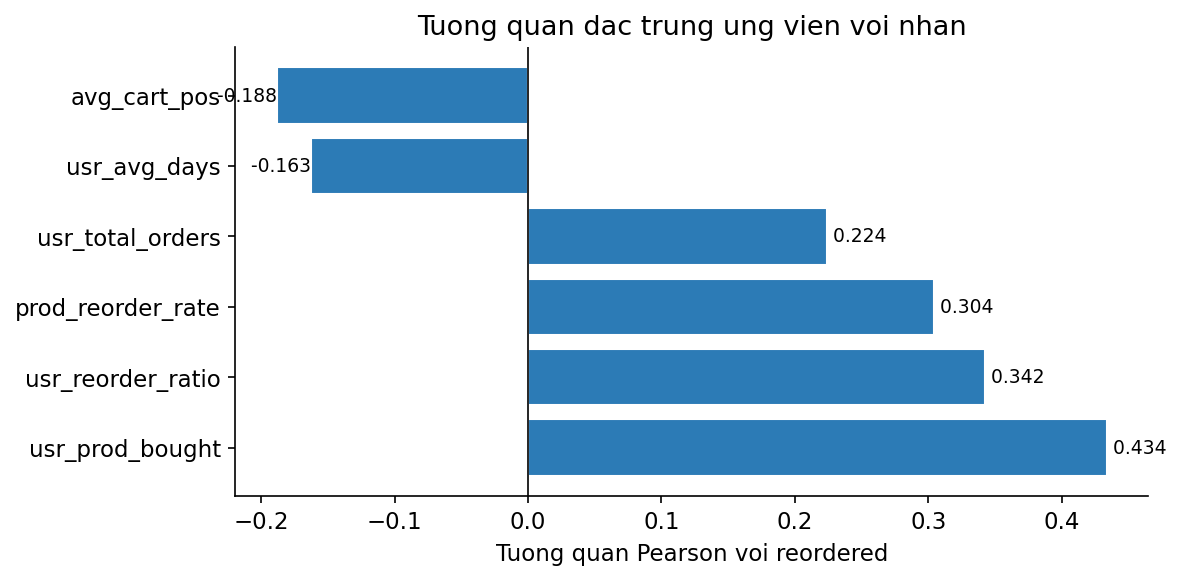

In [9]:
df_feat["has_bought_before"] = (df_feat["user_product_times_bought"] > 0).astype(int)
match_rate = (df_feat["has_bought_before"] == df_feat["reordered"]).mean()
print(f"Ty le has_bought_before == reordered: {match_rate:.4%}")

corr_target = (
    df_feat[CANDIDATE_FEATURES + [TARGET]]
    .corr()[TARGET].drop(TARGET)
    .sort_values(ascending=False)
)
print("\nTuong quan Pearson voi nhan reordered:")
print(corr_target.round(4))

# Dung nhan viet tat tren truc y de bien bieu do gon hon
short_labels = [FEAT_LABELS.get(f, f) for f in corr_target.index]

fig, ax = plt.subplots(figsize=(8, 4))
colors_corr = ["#d7191c" if abs(v) > 0.9 else "#2c7bb6" for v in corr_target.values]
ax.barh(short_labels, corr_target.values, color=colors_corr, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Tuong quan Pearson voi reordered")
ax.set_title("Tuong quan dac trung ung vien voi nhan", fontsize=13)
for i, val in enumerate(corr_target.values):
    ax.text(val, i, f" {val:.3f}", va="center", fontsize=9,
            ha="left" if val >= 0 else "right")
plt.tight_layout()
plt.savefig("output/charts/C0a_leakage_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

### II.2. Kiểm tra đa cộng tuyến (Multicollinearity) <a id="section-II-2"></a>

**Business question:** Các đặc trưng còn lại có trùng tín hiệu với nhau không? Nếu hai đặc trưng tương quan quá cao (ví dụ |r| > 0.8), giữ cả hai không tăng thêm thông tin cho mô hình mà chỉ làm hệ số Logistic Regression khó giải thích hơn.


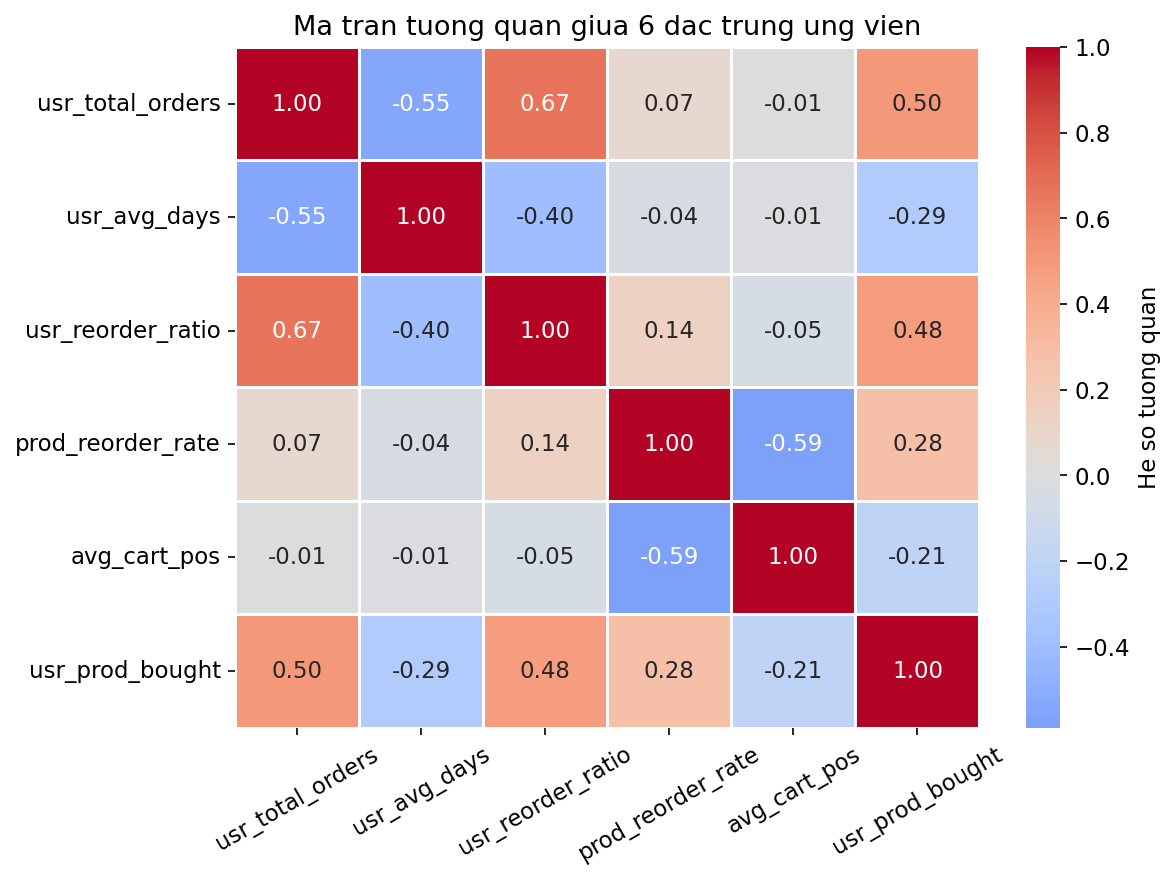

In [10]:
corr_matrix = df_feat[CANDIDATE_FEATURES].corr()

# Doi ten cot va hang sang nhan viet tat
short = [FEAT_LABELS[f] for f in CANDIDATE_FEATURES]
corr_display = corr_matrix.copy()
corr_display.index   = short
corr_display.columns = short

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_display, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "He so tuong quan"})
ax.set_title("Ma tran tuong quan giua 6 dac trung ung vien", fontsize=13)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("output/charts/C0b_feature_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### II.3. Quyết định cuối cùng — Chốt danh sách đặc trưng <a id="section-II-3"></a>

Tổng hợp kết quả 2 bước kiểm định trên thành bảng quyết định Giữ/Loại — đây là phần **mở rộng có minh chứng thực nghiệm** cho Bảng 12 đã trình bày trong báo cáo (Phần III.5).


In [11]:
def quyet_dinh(feat):
    return "LOAI — Data Leakage" if feat == "user_product_times_bought" else "Giu"

def ly_do(feat):
    if feat == "user_product_times_bought":
        return (f"Trung dinh nghia nhan: match_rate = {match_rate:.2%} "
                f"— do lai chinh nhan can du doan, khong phai tin hieu du bao doc lap")
    return "Tuong quan o muc hop ly, giu theo ly do nghiep vu da neu o Bang 12 bao cao"

audit_table = pd.DataFrame({
    "Dac trung": CANDIDATE_FEATURES,
    "Viet tat":  [FEAT_LABELS[f] for f in CANDIDATE_FEATURES],
    "Tuong quan": [round(corr_target.get(f, float("nan")), 4) for f in CANDIDATE_FEATURES],
    "Quyet dinh": [quyet_dinh(f) for f in CANDIDATE_FEATURES],
    "Ly do": [ly_do(f) for f in CANDIDATE_FEATURES],
})
display(audit_table)

FEATURES = [f for f in CANDIDATE_FEATURES if quyet_dinh(f) == "Giu"]
print(f"\nDac trung chinh thuc ({len(FEATURES)}/6): {FEATURES}")

,Dac trung,Viet tat,Tuong quan,Quyet dinh,Ly do
0,user_total_orders,usr_total_orders,0.2239,Giu,"Tuong quan o muc hop ly, giu theo ly do nghiep..."
1,user_avg_days_between_orders,usr_avg_days,-0.1628,Giu,"Tuong quan o muc hop ly, giu theo ly do nghiep..."
2,user_reorder_ratio,usr_reorder_ratio,0.3423,Giu,"Tuong quan o muc hop ly, giu theo ly do nghiep..."
3,product_reorder_rate,prod_reorder_rate,0.3040,Giu,"Tuong quan o muc hop ly, giu theo ly do nghiep..."
4,avg_add_to_cart_position,avg_cart_pos,-0.1883,Giu,"Tuong quan o muc hop ly, giu theo ly do nghiep..."
5,user_product_times_bought,usr_prod_bought,0.4337,LOAI — Data Leakage,Trung dinh nghia nhan: match_rate = 100.00% — ...



Dac trung chinh thuc (5/6): ['user_total_orders', 'user_avg_days_between_orders', 'user_reorder_ratio', 'product_reorder_rate', 'avg_add_to_cart_position']


---

**Phân tích (điền số liệu cụ thể sau khi chạy):**

Kết quả `match_rate` xác nhận `user_product_times_bought` về bản chất là một phép biến đổi tầm thường của nhãn `reordered` (nếu `match_rate` ≥ ~99%) — đây là **data leakage**, không phải tín hiệu dự báo thực sự, nên bị loại trước khi vào bước modeling. Ma trận tương quan ở bước Kiểm tra đa cộng tuyến cho thấy 5 đặc trưng còn lại không có cặp nào tương quan quá cao với nhau (|r| < 0.8) — không có vấn đề đa cộng tuyến nghiêm trọng, có thể giữ đồng thời cả 5 mà không cần loại bớt.

Từ đây, danh sách `FEATURES` (5 đặc trưng) được dùng xuyên suốt cho toàn bộ các bước huấn luyện và đánh giá mô hình ở phần còn lại của notebook.

---

---
## III. Kiểm tra cân bằng nhãn <a id="section-III"></a>

**Business question:** Tỷ lệ nhãn `reordered` có quá lệch (imbalanced) không? Dữ liệu đã đọc ở bước Feature Audit — mục này chỉ kiểm tra phân phối nhãn trước khi chia train/test.

---

Ty le nhan reordered: {1: 0.5986, 0: 0.4014}


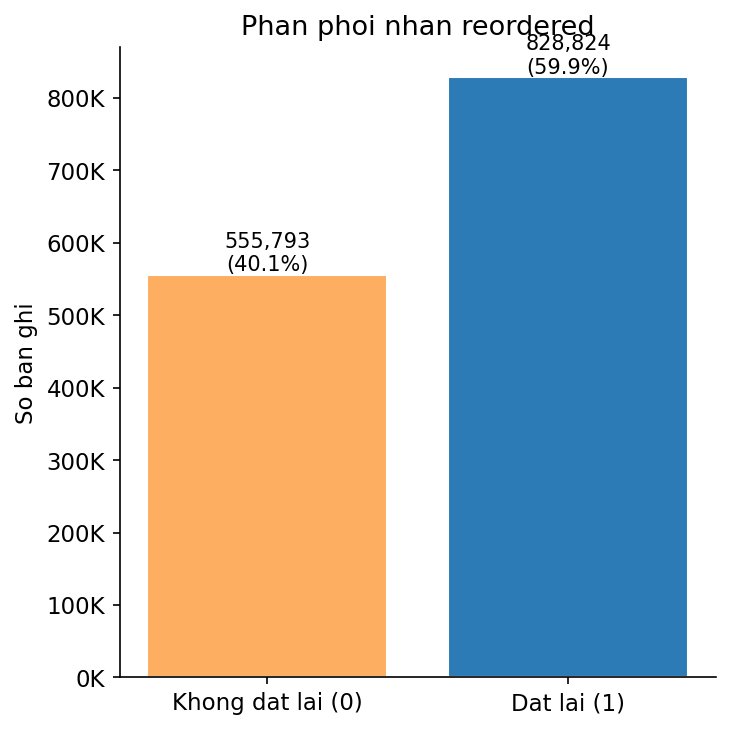

In [12]:
label_dist = df_feat[TARGET].value_counts(normalize=True).round(4)
print("Ty le nhan reordered:", label_dist.to_dict())

fig, ax = plt.subplots(figsize=(5, 5))
counts = df_feat[TARGET].value_counts().sort_index()
bars = ax.bar(["Khong dat lai (0)", "Dat lai (1)"],
              counts.values, color=["#fdae61","#2c7bb6"], edgecolor="white")
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("So ban ghi")
ax.set_title("Phan phoi nhan reordered", fontsize=13)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x>=1e6 else f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.savefig("output/charts/C1_label_balance.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Phân tích:**

Tỷ lệ nhãn ~59%/41% cho thấy dữ liệu **không bị mất cân bằng nghiêm trọng** (mild imbalance) — không cần áp dụng các kỹ thuật xử lý imbalance nặng tay như SMOTE hay class-weighting cực đoan. Tuy nhiên, Precision, Recall, F1 và AUC-ROC vẫn quan trọng hơn Accuracy để đánh giá mô hình một cách công bằng.

---

---
## IV. Chia tập Train/Test <a id="section-IV"></a>

**Mục tiêu:** Tách 80% dữ liệu để huấn luyện, 20% để kiểm tra. Dùng đúng danh sách `FEATURES` (5 đặc trưng) đã chốt ở bước Feature Audit — không dùng lại đặc trưng đã loại.

**Kỹ thuật:** `stratify=y` — giữ đúng tỷ lệ nhãn ở cả hai tập.

---

In [13]:
X = df_feat[FEATURES]
y = df_feat[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Dac trung ({len(FEATURES)}): {FEATURES}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Nhan Train: {y_train.value_counts(normalize=True).round(4).to_dict()}")
print(f"Nhan Test : {y_test.value_counts(normalize=True).round(4).to_dict()}")

Dac trung (5): ['user_total_orders', 'user_avg_days_between_orders', 'user_reorder_ratio', 'product_reorder_rate', 'avg_add_to_cart_position']
Train: 1,107,693 | Test: 276,924
Nhan Train: {1: 0.5986, 0: 0.4014}
Nhan Test : {1: 0.5986, 0: 0.4014}


---
## V. Mô hình 1 — Logistic Regression (GridSearchCV) <a id="section-V"></a>

**Vai trò:** Mô hình cơ sở (baseline) — đơn giản, dễ giải thích, dùng làm điểm tham chiếu cho XGBoost.

**Pipeline:** `StandardScaler → LogisticRegression`. Chuẩn hóa đặc trưng được đưa **vào ngay trong pipeline huấn luyện chính** (không tạo mô hình phụ) — để hệ số dùng giải thích ở mục Hệ số Logistic Regression (chuẩn hóa) phản ánh đúng mô hình đang được dùng để dự đoán, và regularization (`C`) tác động công bằng giữa các đặc trưng có thang đo khác nhau.

**Siêu tham số được tìm kiếm (`param_grid`):**

| Tham số | Giá trị thử | Ý nghĩa |
|---|---|---|
| `logreg__C` | [0.01, 0.1, 1, 10, 100] | Hệ số nghịch đảo của regularization |
| `logreg__penalty` | `l2` | Loại regularization (Ridge) |

**Cách chọn mô hình tốt nhất:** `GridSearchCV` với `cv=3` (`StratifiedKFold`), `scoring='roc_auc'`.

---

In [14]:
t0 = time.time()

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42)),
])
param_grid_lr = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__penalty": ["l2"],
    "logreg__solver": ["lbfgs"],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

lr = grid_lr.best_estimator_
y_pred_lr  = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]

print(f"Thoi gian: {time.time()-t0:.1f}s | Best params: {grid_lr.best_params_}")
print(f"AUC CV: {grid_lr.best_score_:.4f} | AUC Test: {roc_auc_score(y_test, y_prob_lr):.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Thoi gian: 9.7s | Best params: {'logreg__C': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
AUC CV: 0.7535 | AUC Test: 0.7534


---
## VI. Mô hình 2 — XGBoost (GridSearchCV) <a id="section-VI"></a>

**Vai trò:** Mô hình chính — xử lý tốt dữ liệu phi tuyến và tương tác giữa đặc trưng.

**Siêu tham số được tìm kiếm (`param_grid`):**

| Tham số | Giá trị thử | Ý nghĩa |
|---|---|---|
| `n_estimators` | [100, 200] | Số cây boosting tuần tự |
| `max_depth` | [4, 6] | Độ sâu tối đa mỗi cây |
| `learning_rate` | [0.05, 0.1] | Tốc độ học |
| `subsample` | 0.8 (cố định) | Tỷ lệ dữ liệu lấy mẫu cho mỗi cây |

→ 2×2×2 = 8 tổ hợp × 3-fold = **24 lần huấn luyện**.

> **Cảnh báo thời gian:** Có thể mất 10–40 phút tùy máy. Nếu cần nhanh hơn: giảm `param_grid_xgb`, hoặc đổi sang `RandomizedSearchCV(..., n_iter=6, random_state=42)`.

---

In [15]:
t0 = time.time()

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
}
xgb_base = XGBClassifier(subsample=0.8, random_state=42, eval_metric="logloss", n_jobs=-1)
grid_xgb = GridSearchCV(xgb_base, param_grid_xgb, scoring="roc_auc", cv=cv, n_jobs=1, verbose=1)
grid_xgb.fit(X_train, y_train)

xgb = grid_xgb.best_estimator_
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"Thoi gian: {(time.time()-t0)/60:.1f} phut | Best params: {grid_xgb.best_params_}")
print(f"AUC CV: {grid_xgb.best_score_:.4f} | AUC Test: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Thoi gian: 1.4 phut | Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
AUC CV: 0.7575 | AUC Test: 0.7577


---

**Phân tích Logistic Regression và XGBoost (điền số liệu cụ thể sau khi chạy):**

| Mô hình | AUC (Test) | Tham số tốt nhất |
|---|---|---|
| Logistic Regression | *(xem print ở bước Logistic Regression)* | *(xem `grid_lr.best_params_`)* |
| XGBoost | *(xem print ở bước XGBoost)* | *(xem `grid_xgb.best_params_`)* |

- Nếu **XGBoost > Logistic Regression rõ rệt**: dữ liệu có tương tác phi tuyến giữa đặc trưng mà Logistic Regression không nắm bắt được.
- Nếu **AUC hai mô hình gần nhau**: quan hệ giữa các đặc trưng và `reordered` tương đối tuyến tính.

*(Sau khi loại bỏ đặc trưng leakage ở bước Feature Audit, AUC ở bước này phản ánh khả năng học thực sự của mô hình — không còn là 1.0000 "ảo" như trước.)*

---

---
## VII. Learning Curve — kiểm tra Overfitting <a id="section-VII"></a>

**Business question:** Mô hình có bị overfit không? Train AUC và Test AUC có hội tụ khi thêm dữ liệu không?

- **3 đường:** Train AUC (xanh dương), Validation AUC / CV (đỏ), Test AUC (xanh lá).
- **Gap nhỏ** (Train - Test < 0.02): không có dấu hiệu overfitting.
- **Cả 3 hội tụ** ở phần phải: mô hình đã bão hòa với lượng data hiện tại.

> Lưu ý: mỗi điểm trên đường Test AUC yêu cầu train lại mô hình từ đầu trên một subset — XGBoost có thể mất 5–15 phút.

---

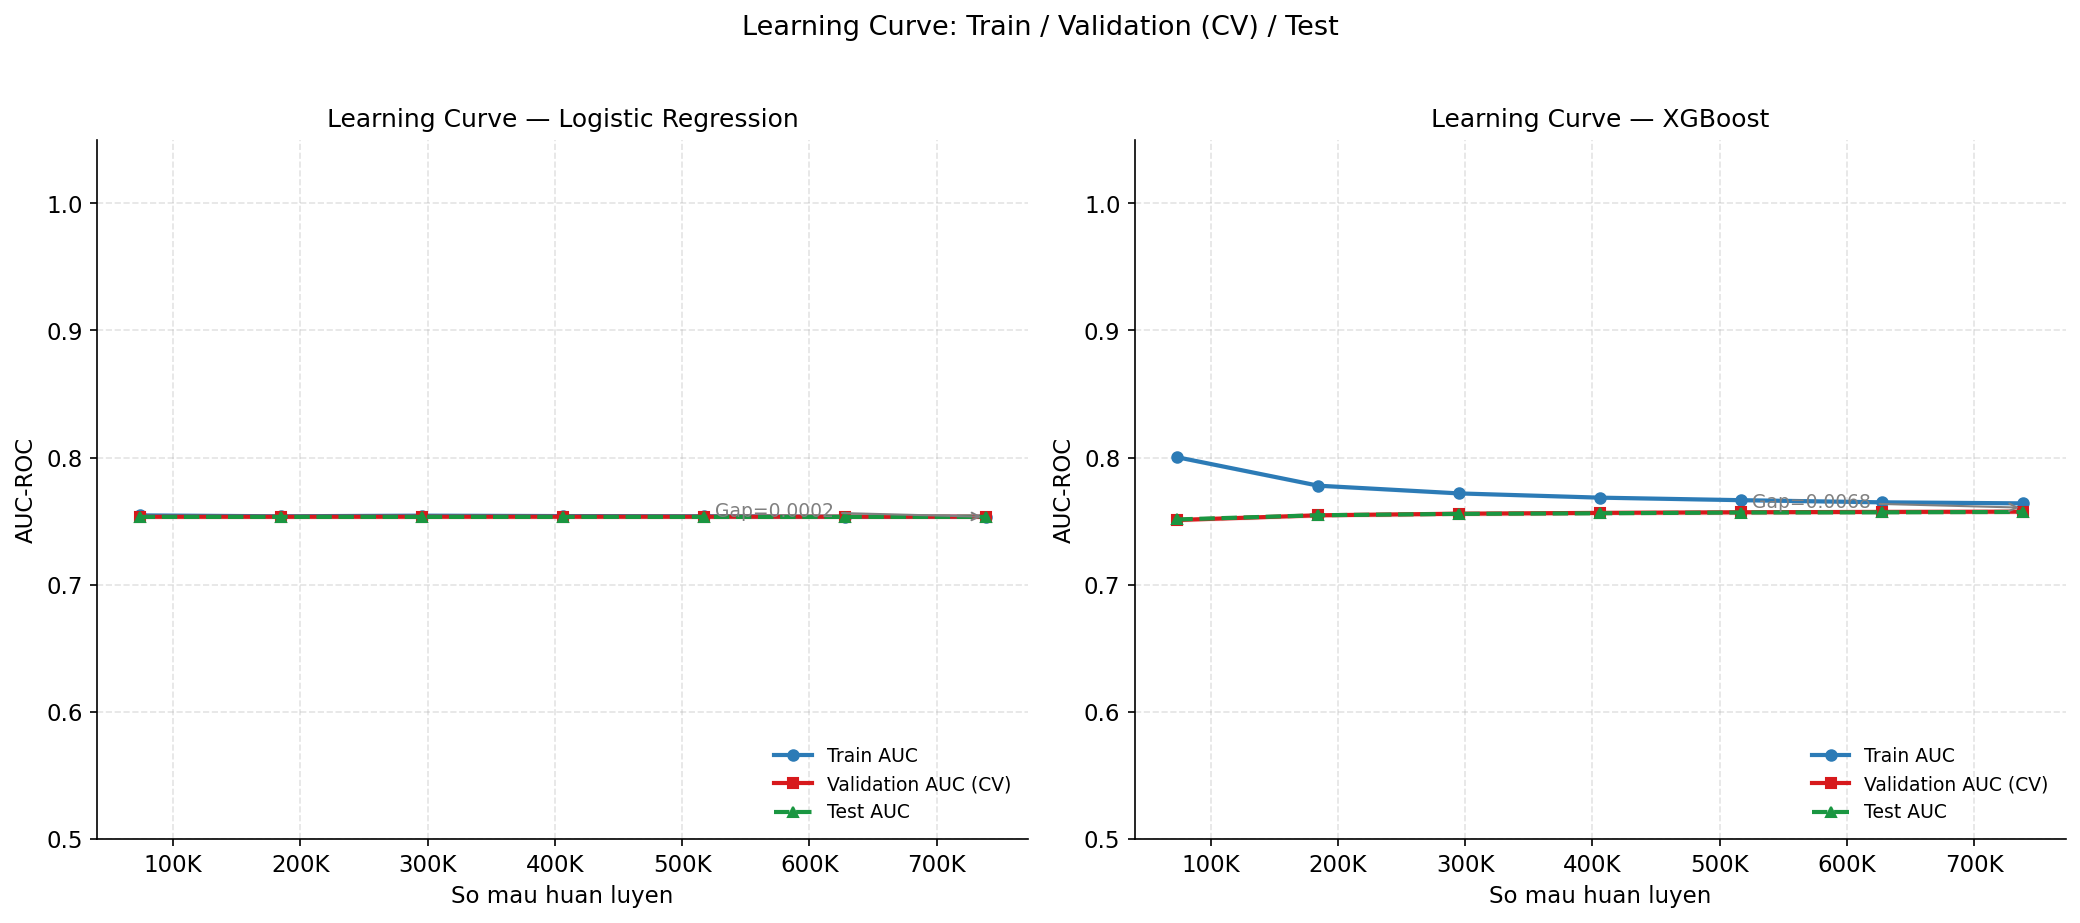


Kiem tra overfitting (Gap = Train AUC - Test AUC tai kich thuoc day du):
  Logistic Regression       | Gap=0.0002 | Tot
  XGBoost                   | Gap=0.0068 | Tot


In [16]:
def plot_lc_with_test(estimator, X_tr, y_tr, X_te, y_te, title, ax, cv=3,
                     train_sizes=np.linspace(0.1, 1.0, 7)):
    ts, tr_s, val_s = learning_curve(
        estimator, X_tr, y_tr, train_sizes=train_sizes,
        cv=StratifiedKFold(cv, shuffle=True, random_state=42),
        scoring="roc_auc", n_jobs=-1,
    )
    tr_m, tr_std = tr_s.mean(1), tr_s.std(1)
    val_m, val_std = val_s.mean(1), val_s.std(1)

    rng = np.random.RandomState(42)
    te_aucs = []
    for size in ts:
        idx = rng.choice(len(X_tr), int(size), replace=False)
        m = clone(estimator)
        m.fit(X_tr.iloc[idx], y_tr.iloc[idx])
        te_aucs.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
    te_aucs = np.array(te_aucs)

    ax.fill_between(ts, tr_m-tr_std, tr_m+tr_std, alpha=0.12, color="#2c7bb6")
    ax.fill_between(ts, val_m-val_std, val_m+val_std, alpha=0.12, color="#d7191c")
    ax.plot(ts, tr_m, "o-", color="#2c7bb6", lw=2, ms=5, label="Train AUC")
    ax.plot(ts, val_m, "s-", color="#d7191c", lw=2, ms=5, label="Validation AUC (CV)")
    ax.plot(ts, te_aucs, "^--", color="#1a9641", lw=2, ms=5, label="Test AUC")

    gap = float(tr_m[-1] - te_aucs[-1])
    ax.annotate(f"Gap={gap:.4f}",
        xy=(ts[-1], (tr_m[-1]+te_aucs[-1])/2),
        xytext=(-130,0), textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9, color="gray")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("So mau huan luyen")
    ax.set_ylabel("AUC-ROC")
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.set_ylim(0.5, 1.05)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}K"))
    return gap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gap_lr  = plot_lc_with_test(lr,  X_train, y_train, X_test, y_test,
                             "Learning Curve — Logistic Regression", axes[0])
gap_xgb = plot_lc_with_test(xgb, X_train, y_train, X_test, y_test,
                             "Learning Curve — XGBoost", axes[1])

plt.suptitle("Learning Curve: Train / Validation (CV) / Test", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("output/charts/C4b_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKiem tra overfitting (Gap = Train AUC - Test AUC tai kich thuoc day du):")
for name, gap in [("Logistic Regression", gap_lr), ("XGBoost", gap_xgb)]:
    verdict = "Tot" if gap < 0.02 else ("Nhe" if gap < 0.05 else "Ro — nen tang regularization")
    print(f"  {name:25s} | Gap={gap:.4f} | {verdict}")

---
## VIII. Ma trận nhầm lẫn & Classification Report <a id="section-VIII"></a>

**Business question:** Mô hình dự đoán đúng/sai như thế nào ở từng nhãn? Loại lỗi nào mô hình mắc nhiều hơn — bỏ sót (FN) hay gợi ý sai (FP)?

---

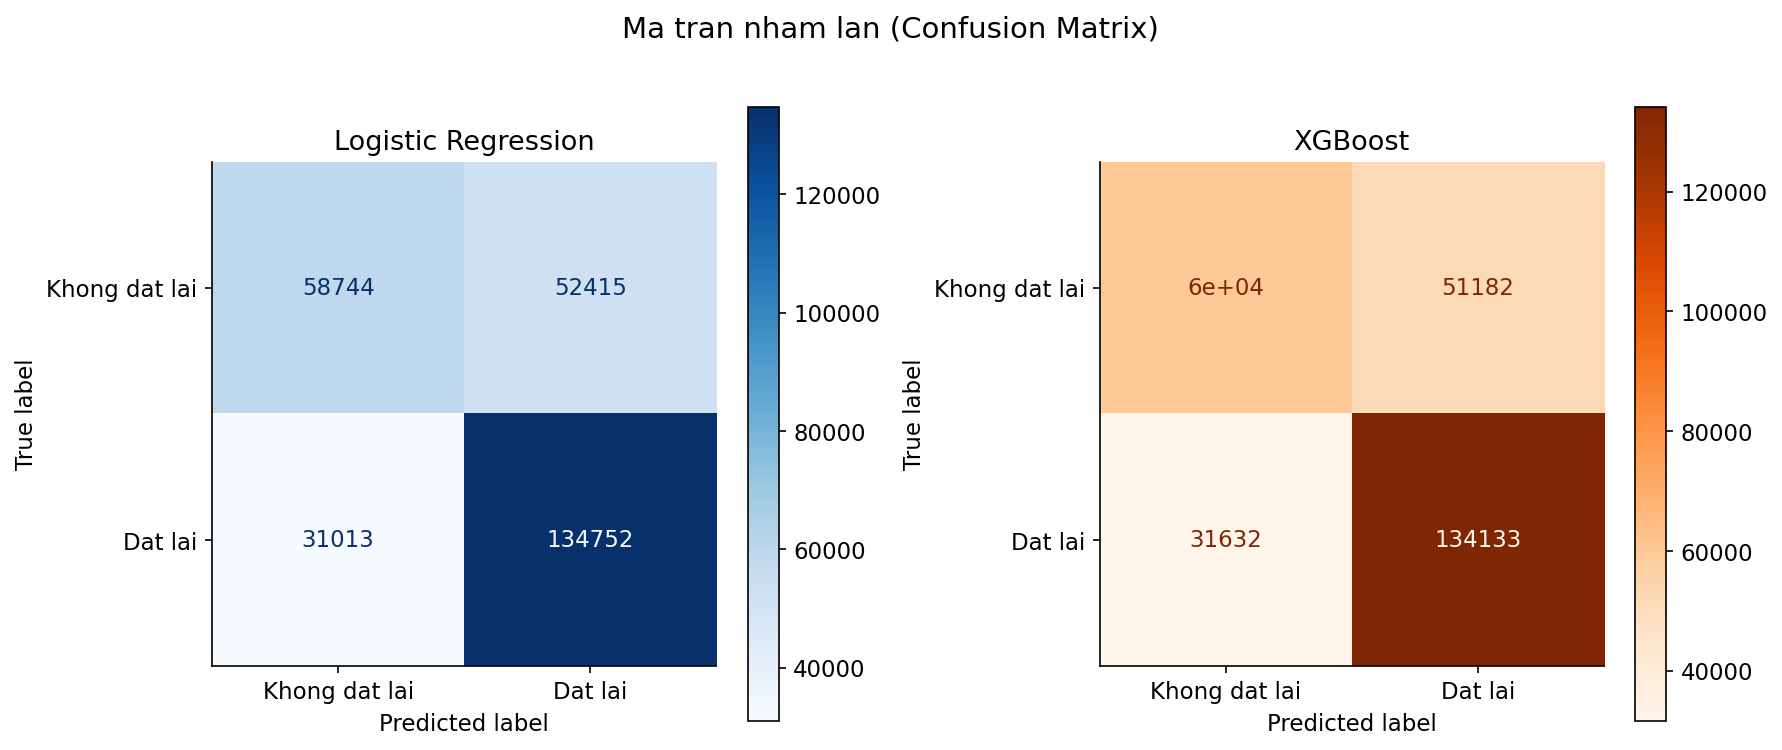

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[0], cmap="Blues",
    display_labels=["Khong dat lai", "Dat lai"])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, ax=axes[1], cmap="Oranges",
    display_labels=["Khong dat lai", "Dat lai"])
axes[1].set_title("XGBoost")

plt.suptitle("Ma tran nham lan (Confusion Matrix)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("output/charts/C5_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
print("="*55)
print("LOGISTIC REGRESSION - Classification Report")
print("="*55)
print(classification_report(y_test, y_pred_lr, target_names=["Khong dat lai","Dat lai"]))
print("="*55)
print("XGBOOST - Classification Report")
print("="*55)
print(classification_report(y_test, y_pred_xgb, target_names=["Khong dat lai","Dat lai"]))

LOGISTIC REGRESSION - Classification Report
               precision    recall  f1-score   support

Khong dat lai       0.65      0.53      0.58    111159
      Dat lai       0.72      0.81      0.76    165765

     accuracy                           0.70    276924
    macro avg       0.69      0.67      0.67    276924
 weighted avg       0.69      0.70      0.69    276924

XGBOOST - Classification Report
               precision    recall  f1-score   support

Khong dat lai       0.65      0.54      0.59    111159
      Dat lai       0.72      0.81      0.76    165765

     accuracy                           0.70    276924
    macro avg       0.69      0.67      0.68    276924
 weighted avg       0.70      0.70      0.69    276924



---

**Phân tích (điền số liệu cụ thể sau khi chạy):**

So sánh 2 ma trận nhầm lẫn cho biết mô hình nào mắc nhiều False Negative (bỏ sót sản phẩm thực sự được đặt lại) hơn — loại lỗi tốn kém hơn với bài toán gợi ý mua lại. Nếu Recall của lớp "Đặt lại" ở XGBoost cao hơn trong khi Precision không giảm nhiều, đây là minh chứng XGBoost phù hợp hơn cho mục tiêu "không bỏ sót gợi ý".

---

---
## IX. Bảng dự đoán mẫu trên tập Test <a id="section-IX"></a>

**Mục tiêu:** Minh họa trực quan cách hai mô hình dự đoán trên từng bản ghi cụ thể — gồm 10 mẫu XGBoost đúng và 10 mẫu XGBoost sai để so sánh xác suất dự đoán với kết quả thực tế.

---

In [19]:
pred_df = X_test.copy()
pred_df["actual"]    = y_test.values
pred_df["prob_xgb"]  = y_prob_xgb.round(3)
pred_df["prob_lr"]   = y_prob_lr.round(3)
pred_df["pred_xgb"]  = y_pred_xgb
pred_df["pred_lr"]   = y_pred_lr
pred_df["xgb_ok"]    = (pred_df["pred_xgb"] == pred_df["actual"]).astype(int)
pred_df["lr_ok"]     = (pred_df["pred_lr"]  == pred_df["actual"]).astype(int)

s_ok   = pred_df[pred_df["xgb_ok"]==1].sample(10, random_state=42)
s_fail = pred_df[pred_df["xgb_ok"]==0].sample(10, random_state=42)
samp   = pd.concat([s_ok.assign(nhom="XGB_Dung"),
                    s_fail.assign(nhom="XGB_Sai")], ignore_index=True)

# Dung chung FEAT_LABELS (da khai bao o dau bai) de dat ten cot ngan gon
samp = samp.rename(columns=FEAT_LABELS)
samp["actual"]   = samp["actual"].map({1:"Dat lai",0:"Khong dat lai"})
samp["pred_xgb"] = samp["pred_xgb"].map({1:"Dat lai",0:"Khong dat lai"})
samp["pred_lr"]  = samp["pred_lr"].map({1:"Dat lai",0:"Khong dat lai"})
samp["xgb_ok"]   = samp["xgb_ok"].map({1:"Dung",0:"Sai"})
samp["lr_ok"]    = samp["lr_ok"].map({1:"Dung",0:"Sai"})

cols = ["nhom", *[FEAT_LABELS[f] for f in FEATURES if f in FEAT_LABELS],
        "actual","prob_xgb","pred_xgb","xgb_ok","prob_lr","pred_lr","lr_ok"]
out = samp[cols].reset_index(drop=True)
for f in FEATURES:
    if f in FEAT_LABELS:
        col = FEAT_LABELS[f]
        out[col] = out[col].apply(lambda x: f"{x:.3f}")

print("Bang du doan mau — 10 XGB Dung + 10 XGB Sai")
print("-"*70)
display(out)

print(f"\nXGBoost    dung: {pred_df['xgb_ok'].mean():.1%} ({pred_df['xgb_ok'].sum():,}/{len(pred_df):,})")
print(f"Log.Regr.  dung: {pred_df['lr_ok'].mean():.1%}  ({pred_df['lr_ok'].sum():,}/{len(pred_df):,})")

Bang du doan mau — 10 XGB Dung + 10 XGB Sai
----------------------------------------------------------------------


,nhom,usr_total_orders,usr_avg_days,usr_reorder_ratio,prod_reorder_rate,avg_cart_pos,actual,prob_xgb,pred_xgb,xgb_ok,prob_lr,pred_lr,lr_ok
0,XGB_Dung,24.000,8.458,0.322,0.707,6.455,Dat lai,0.626,Dat lai,Dung,0.677,Dat lai,Dung
1,XGB_Dung,4.000,18.000,0.311,0.273,10.036,Khong dat lai,0.230,Khong dat lai,Dung,0.209,Khong dat lai,Dung
2,XGB_Dung,7.000,16.000,0.115,0.525,9.003,Khong dat lai,0.291,Khong dat lai,Dung,0.282,Khong dat lai,Dung
3,XGB_Dung,4.000,12.000,0.286,0.473,8.255,Khong dat lai,0.381,Khong dat lai,Dung,0.390,Khong dat lai,Dung
4,XGB_Dung,6.000,12.333,0.404,0.603,8.820,Dat lai,0.622,Dat lai,Dung,0.604,Dat lai,Dung
5,XGB_Dung,5.000,16.000,0.333,0.582,10.089,Khong dat lai,0.473,Khong dat lai,Dung,0.492,Khong dat lai,Dung
6,XGB_Dung,5.000,19.400,0.309,0.000,11.571,Khong dat lai,0.101,Khong dat lai,Dung,0.076,Khong dat lai,Dung
7,XGB_Dung,8.000,22.375,0.305,0.662,7.514,Dat lai,0.592,Dat lai,Dung,0.550,Dat lai,Dung
8,XGB_Dung,17.000,11.059,0.593,0.685,6.191,Dat lai,0.783,Dat lai,Dung,0.825,Dat lai,Dung
9,XGB_Dung,8.000,22.250,0.221,0.512,8.204,Khong dat lai,0.396,Khong dat lai,Dung,0.332,Khong dat lai,Dung



XGBoost    dung: 70.1% (194,110/276,924)
Log.Regr.  dung: 69.9%  (193,496/276,924)


---
## X. So sánh đường cong ROC <a id="section-X"></a>

**Business question:** Mô hình phân biệt giữa hai nhóm tốt đến mức nào trên mọi ngưỡng quyết định?

| | |
|---|---|
| **AUC-ROC** | 0.5 = đoán ngẫu nhiên, 1.0 = phân biệt hoàn hảo |

---

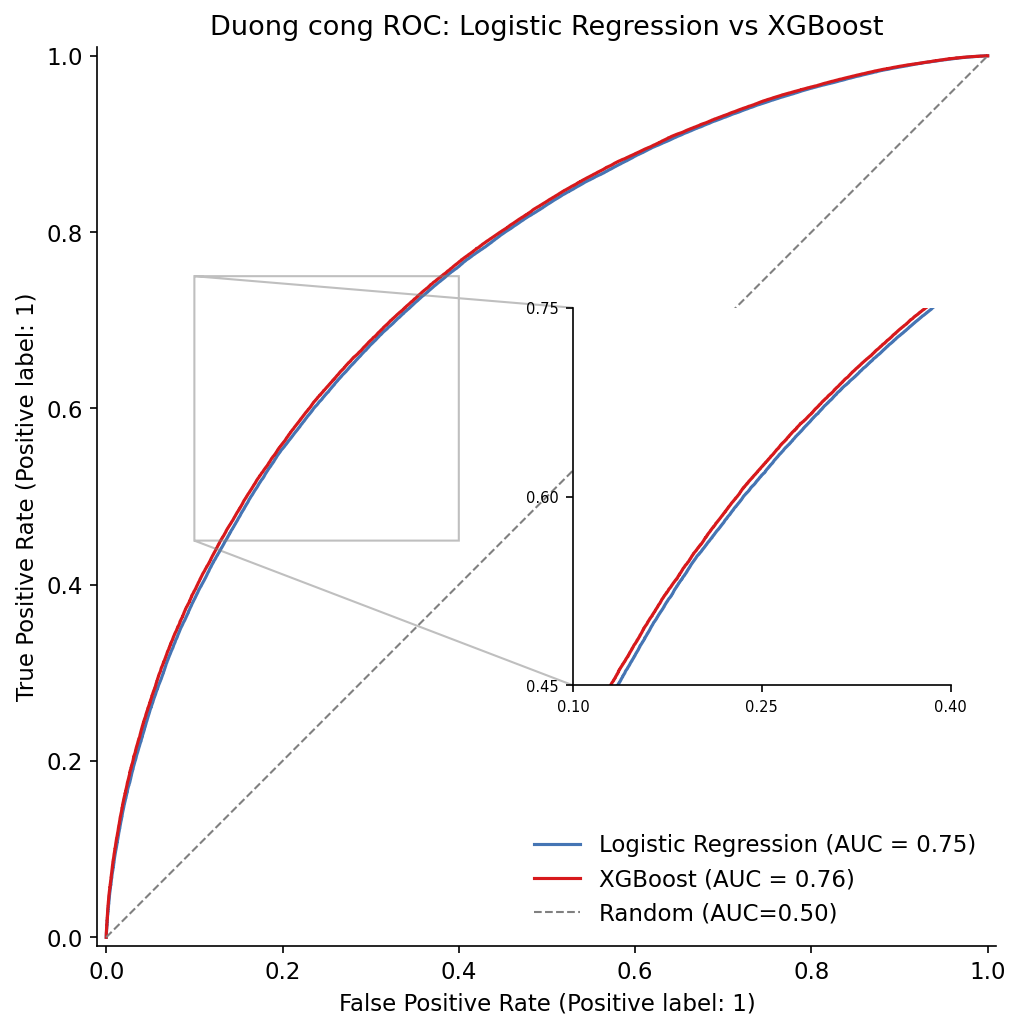

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))

disp_lr  = RocCurveDisplay.from_predictions(y_test, y_prob_lr,  ax=ax, name="Logistic Regression")
disp_lr.line_.set_color("#4575b4")
disp_xgb = RocCurveDisplay.from_predictions(y_test, y_prob_xgb, ax=ax, name="XGBoost")
disp_xgb.line_.set_color("#d7191c")
ax.plot([0,1],[0,1],"--",color="gray",lw=1,label="Random (AUC=0.50)")
ax.set_title("Duong cong ROC: Logistic Regression vs XGBoost", fontsize=13)
ax.legend(loc="lower right", frameon=False)

# Khung phong to vung giua de thay ro khoang cach
axins = inset_axes(ax, width="42%", height="42%", loc="center right", borderpad=2)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
axins.plot(fpr_lr,  tpr_lr,  color="#4575b4")
axins.plot(fpr_xgb, tpr_xgb, color="#d7191c")
axins.set_xlim(0.1, 0.4); axins.set_ylim(0.45, 0.75)
axins.set_xticks([0.1,0.25,0.4]); axins.set_yticks([0.45,0.6,0.75])
axins.tick_params(labelsize=7)
ax.indicate_inset_zoom(axins, edgecolor="gray")

plt.tight_layout()
plt.savefig("output/charts/C6_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### XI. Bootstrap — kiểm định ý nghĩa thống kê của chênh lệch AUC <a id="section-XI"></a>

**Mục tiêu:** Kiểm tra xem AUC(XGBoost) > AUC(LR) ~0.01 có đáng tin hay chỉ là nhiễu của 1 lần chia test.
Nếu **95% CI không chứa 0** → chênh lệch có ý nghĩa thống kê dù nhỏ về giá trị tuyệt đối.


Chenh lech AUC trung binh (XGB - LR): 0.0043
95% CI: [0.0040, 0.0046]
XGB khong vuot LR: 0.00%


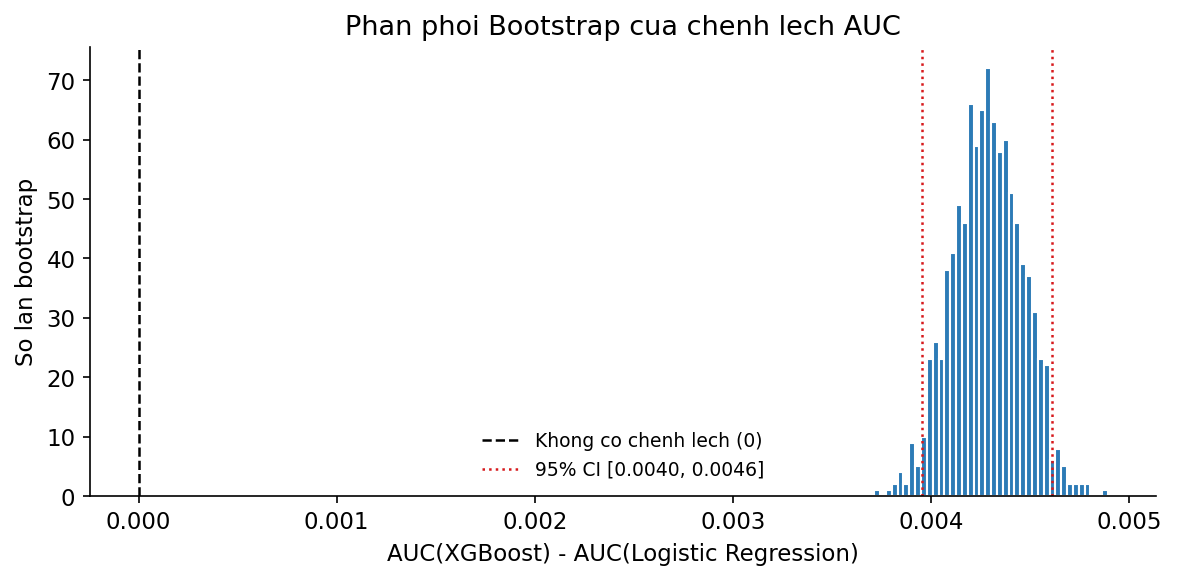

In [21]:
rng2 = np.random.RandomState(42)
y_arr = y_test.values
diffs = []
for _ in range(1000):
    idx = rng2.randint(0, len(y_arr), len(y_arr))
    ys = y_arr[idx]
    if len(np.unique(ys)) < 2: continue
    diffs.append(roc_auc_score(ys, y_prob_xgb[idx]) - roc_auc_score(ys, y_prob_lr[idx]))
diffs = np.array(diffs)
ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])

print(f"Chenh lech AUC trung binh (XGB - LR): {diffs.mean():.4f}")
print(f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"XGB khong vuot LR: {(diffs<=0).mean():.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diffs, bins=40, color="#2c7bb6", edgecolor="white")
ax.axvline(0,    color="black", ls="--", lw=1.2, label="Khong co chenh lech (0)")
ax.axvline(ci_lo, color="#d7191c", ls=":", lw=1.2, label=f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
ax.axvline(ci_hi, color="#d7191c", ls=":", lw=1.2)
ax.set_xlabel("AUC(XGBoost) - AUC(Logistic Regression)")
ax.set_ylabel("So lan bootstrap")
ax.set_title("Phan phoi Bootstrap cua chenh lech AUC", fontsize=13)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("output/charts/C6b_auc_bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Phân tích (điền số liệu cụ thể sau khi chạy):**

Đường cong càng "phình" về phía góc trên-trái thể hiện mô hình phân biệt tốt hơn. So sánh AUC của 2 mô hình cho thấy mô hình nào có khả năng phân biệt tổng thể tốt hơn trên *mọi* ngưỡng — chỉ số tổng quan trước khi đi sâu vào chọn ngưỡng cụ thể ở bước Precision-Recall Curve.

---

---
## XII. Precision-Recall Curve & Phân tích Threshold <a id="section-XII"></a>

**Business question:** Ngưỡng quyết định 0.5 mặc định có phải là lựa chọn tốt nhất không?

| | |
|---|---|
| **Tại sao cần PR Curve** | Với dữ liệu hơi lệch nhãn, PR Curve phản ánh hiệu suất ở lớp thiểu số rõ hơn ROC Curve |

---

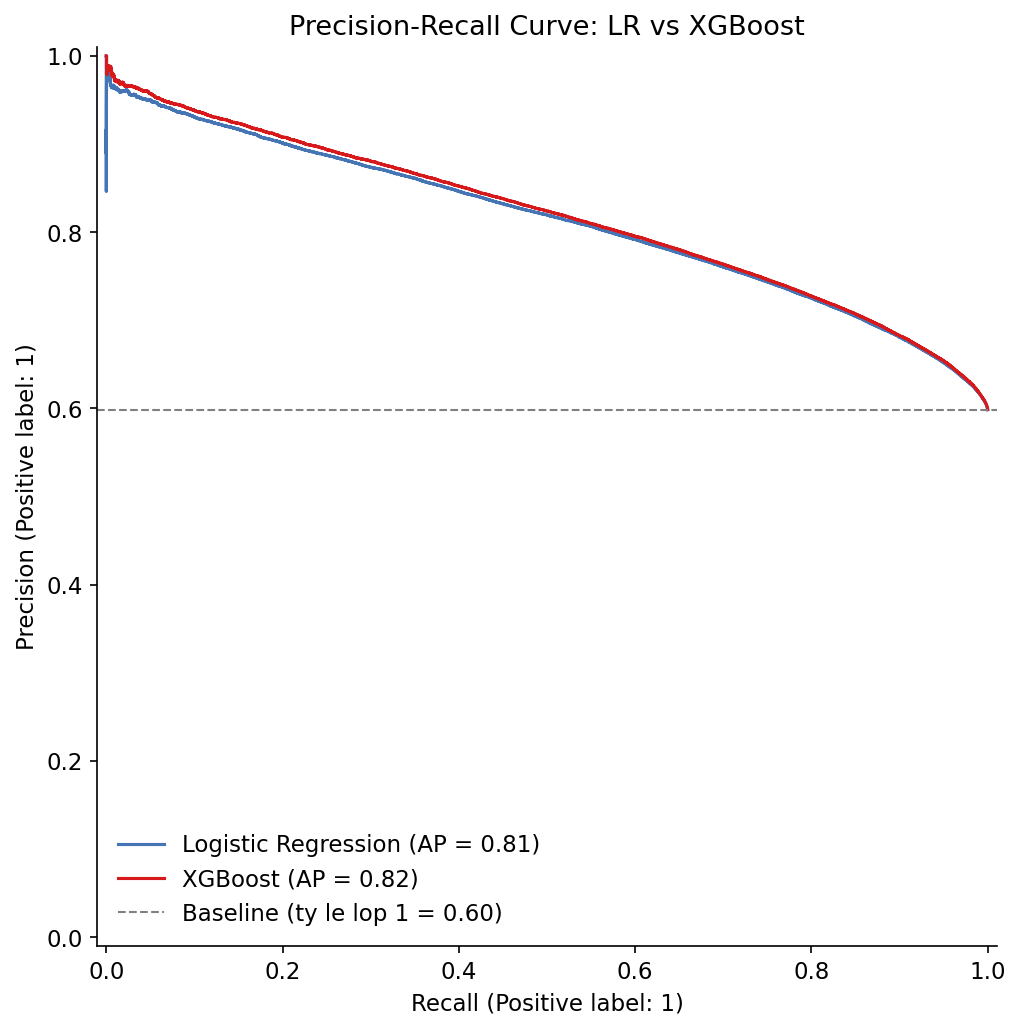

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))
disp_pr_lr  = PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr,  ax=ax, name="Logistic Regression")
disp_pr_lr.line_.set_color("#4575b4")
disp_pr_xgb = PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb, ax=ax, name="XGBoost")
disp_pr_xgb.line_.set_color("#d7191c")
baseline = y_test.mean()
ax.axhline(baseline, ls="--", color="gray", lw=1,
           label=f"Baseline (ty le lop 1 = {baseline:.2f})")
ax.set_title("Precision-Recall Curve: LR vs XGBoost", fontsize=13)
ax.legend(loc="lower left", frameon=False)
plt.tight_layout()
plt.savefig("output/charts/C7a_precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Nguong toi uu F1 (XGBoost): 0.393
  Precision=0.6786 | Recall=0.9087 | F1=0.7770
Nguong mac dinh 0.5:
  Precision=0.7238 | Recall=0.8092 | F1=0.7641


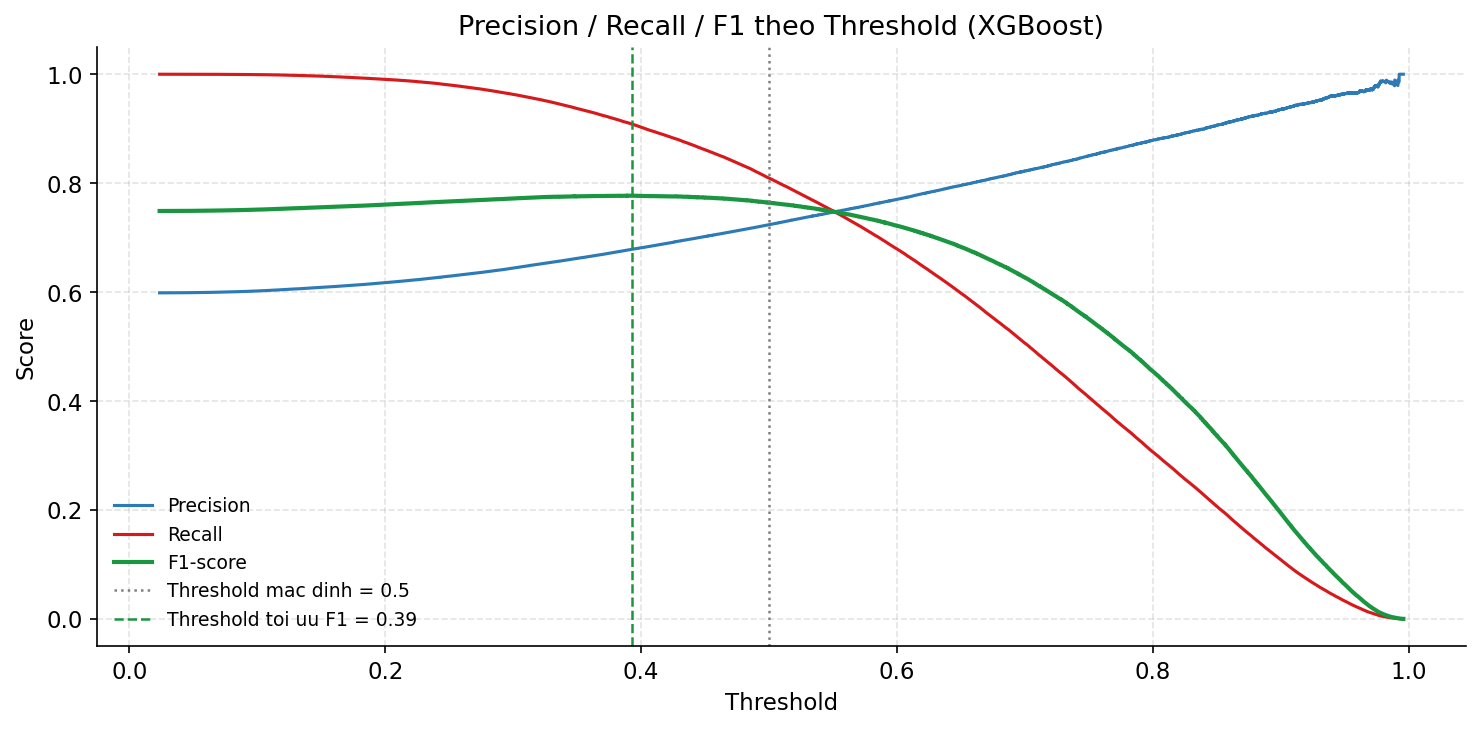

In [23]:
prec, rec, thr = precision_recall_curve(y_test, y_prob_xgb)
f1s = 2*prec*rec/(prec+rec+1e-12)
best_idx = np.argmax(f1s[:-1])
best_thr = thr[best_idx]

print(f"Nguong toi uu F1 (XGBoost): {best_thr:.3f}")
print(f"  Precision={prec[best_idx]:.4f} | Recall={rec[best_idx]:.4f} | F1={f1s[best_idx]:.4f}")
print(f"Nguong mac dinh 0.5:")
print(f"  Precision={precision_score(y_test,y_pred_xgb):.4f} | Recall={recall_score(y_test,y_pred_xgb):.4f} | F1={f1_score(y_test,y_pred_xgb):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr, prec[:-1], color="#2c7bb6", label="Precision")
ax.plot(thr, rec[:-1],  color="#d7191c", label="Recall")
ax.plot(thr, f1s[:-1],  color="#1a9641", lw=2, label="F1-score")
ax.axvline(0.5,    ls=":", color="gray",    lw=1.2, label="Threshold mac dinh = 0.5")
ax.axvline(best_thr, ls="--", color="#1a9641", lw=1.2,
           label=f"Threshold toi uu F1 = {best_thr:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 theo Threshold (XGBoost)", fontsize=13)
ax.legend(loc="lower left", frameon=False, fontsize=9)
ax.grid(True, ls="--", alpha=0.35)
plt.tight_layout()
plt.savefig("output/charts/C7b_threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
rows = []
for th in sorted({0.3, 0.4, 0.5, round(float(best_thr),2), 0.6, 0.7}):
    p = (y_prob_xgb >= th).astype(int)
    rows.append({"Threshold": th,
                 "Precision": precision_score(y_test, p, zero_division=0),
                 "Recall":    recall_score(y_test, p, zero_division=0),
                 "F1":        f1_score(y_test, p, zero_division=0)})
display(pd.DataFrame(rows).round(4))

,Threshold,Precision,Recall,F1
0,0.30,0.6440,0.9630,0.7719
1,0.39,0.6776,0.9105,0.7770
2,0.40,0.6814,0.9026,0.7765
3,0.50,0.7238,0.8092,0.7641
4,0.60,0.7703,0.6787,0.7216
5,0.70,0.8223,0.5059,0.6264


---

**Phân tích (điền số liệu cụ thể sau khi chạy):**

Khi tăng threshold, Precision tăng nhưng Recall giảm, và ngược lại. Ngưỡng tối ưu theo F1 là điểm cân bằng, nhưng không nhất thiết là lựa chọn tốt nhất cho kinh doanh:

- Ưu tiên **không bỏ sót khách sẽ mua lại** → hạ threshold để tăng Recall.
- Ưu tiên **tránh gợi ý sai** (ví dụ thông báo đẩy/email) → tăng threshold để ưu tiên Precision.

Khuyến nghị: trình bày `threshold_table` trong báo cáo để minh họa lựa chọn ngưỡng theo mục tiêu kinh doanh thực tế.

---

---
## XIII. Độ quan trọng của đặc trưng (Feature Importance) <a id="section-XIII"></a>

**Business question:** Trong 5 đặc trưng đã qua kiểm định ở bước Feature Audit, đặc trưng nào ảnh hưởng nhiều nhất đến quyết định đặt lại sản phẩm?

| | |
|---|---|
| **Nguồn — XGBoost** | `xgb.feature_importances_` — tổng Gain qua các lần chia nhánh |
| **Nguồn — Logistic Regression** | Hệ số từ bước `logreg` trong Pipeline đã fit ở bước Logistic Regression (đặc trưng đã được `StandardScaler` chuẩn hóa ngay trong pipeline, nên hệ số so sánh được công bằng giữa các đặc trưng) |

---

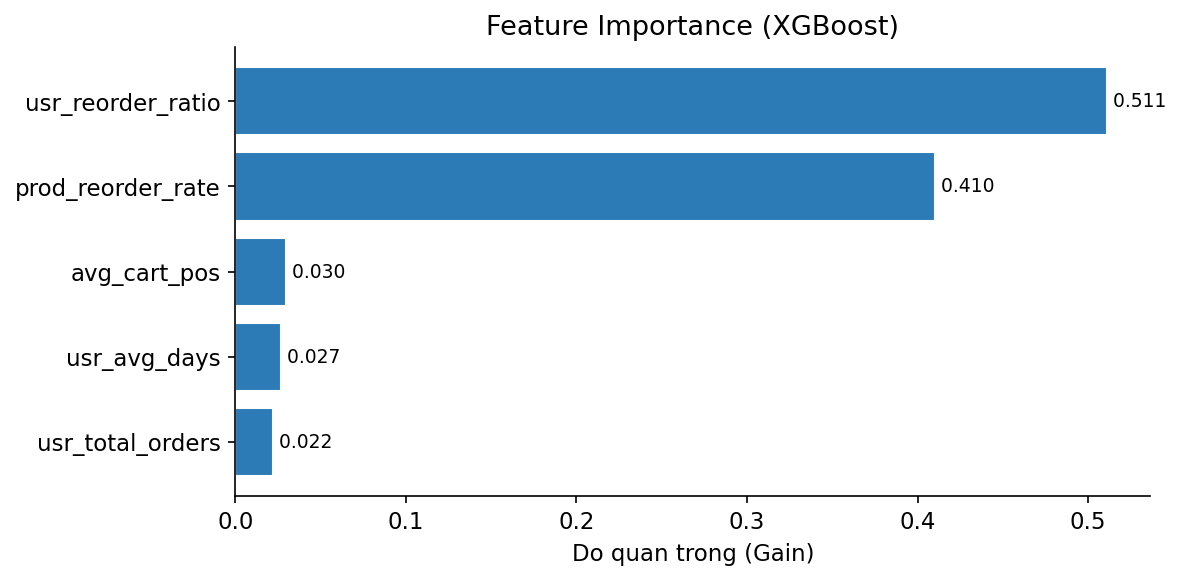

,Dac trung (goc),Viet tat,Do quan trong
2,user_reorder_ratio,usr_reorder_ratio,0.510992
3,product_reorder_rate,prod_reorder_rate,0.410178
4,avg_add_to_cart_position,avg_cart_pos,0.029909
1,user_avg_days_between_orders,usr_avg_days,0.026744
0,user_total_orders,usr_total_orders,0.022178


In [25]:
feat_imp = pd.DataFrame({
    "Dac trung": [FEAT_LABELS[f] for f in FEATURES],   # nhan viet tat
    "Do quan trong": xgb.feature_importances_
}).sort_values("Do quan trong", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_imp["Dac trung"], feat_imp["Do quan trong"],
        color="#2c7bb6", edgecolor="white")
ax.set_xlabel("Do quan trong (Gain)")
ax.set_title("Feature Importance (XGBoost)", fontsize=13)
for i, val in enumerate(feat_imp["Do quan trong"]):
    ax.text(val, i, f" {val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("output/charts/C8a_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Bang day du voi ten goc de tham khao
fi_full = pd.DataFrame({
    "Dac trung (goc)": FEATURES,
    "Viet tat":        [FEAT_LABELS[f] for f in FEATURES],
    "Do quan trong":   xgb.feature_importances_,
}).sort_values("Do quan trong", ascending=False)
display(fi_full)

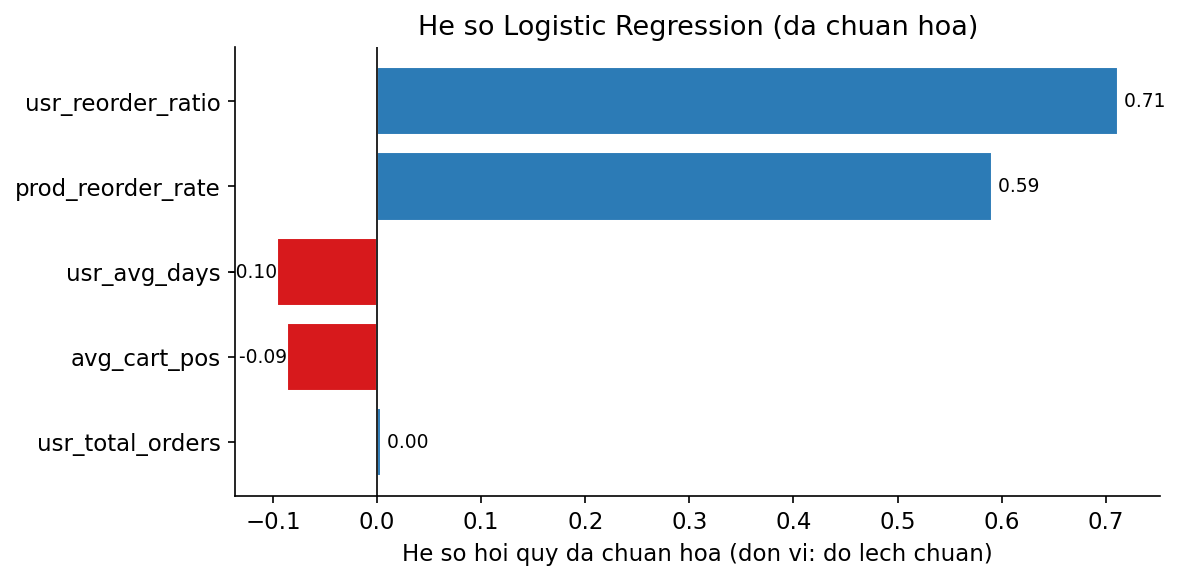

In [26]:
logreg_step = lr.named_steps["logreg"]
coef_lr = pd.DataFrame({
    "Dac trung": [FEAT_LABELS[f] for f in FEATURES],   # nhan viet tat
    "He so (chuan hoa)": logreg_step.coef_[0]
})
coef_lr["abs"] = coef_lr["He so (chuan hoa)"].abs()
coef_lr = coef_lr.sort_values("abs", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_c = ["#d7191c" if v < 0 else "#2c7bb6" for v in coef_lr["He so (chuan hoa)"]]
ax.barh(coef_lr["Dac trung"], coef_lr["He so (chuan hoa)"],
        color=colors_c, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("He so hoi quy da chuan hoa (don vi: do lech chuan)")
ax.set_title("He so Logistic Regression (da chuan hoa)", fontsize=13)
for i, val in enumerate(coef_lr["He so (chuan hoa)"]):
    ax.text(val, i, f" {val:.2f}", va="center", fontsize=9,
            ha="left" if val >= 0 else "right")
plt.tight_layout()
plt.savefig("output/charts/C8b_lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Phân tích (điền số liệu cụ thể sau khi chạy):**

So sánh thứ tự đặc trưng quan trọng nhất giữa XGBoost (Gain) và Logistic Regression (hệ số chuẩn hóa) với giả thuyết nghiệp vụ đã đặt ra ở Bảng 12 báo cáo:

- Nếu `user_reorder_ratio` hoặc `product_reorder_rate` có hệ số dương rõ rệt → xác nhận "hành vi đặt lại có tính quán tính" như đã giả định.
- Nếu `avg_add_to_cart_position` có hệ số âm (vị trí thêm giỏ sớm hơn → dễ được mua lại hơn) → khớp với lý luận đã nêu khi chọn đặc trưng này.
- Nếu có đặc trưng nào xếp hạng khác xa kỳ vọng ban đầu → nêu rõ trong phần kết luận kèm giải thích khả thi.

---

---
## XIV. Xuất model_results.csv cho Power BI <a id="section-XIV"></a>

**Mục tiêu:** Tổng hợp các chỉ số đánh giá của cả hai mô hình (đã huấn luyện trên 5 đặc trưng đã qua kiểm định ở bước Feature Audit) thành một file CSV cho Power BI.

---

In [27]:
results = pd.DataFrame({
    "Mo_hinh":    ["Logistic Regression", "XGBoost"],
    "So_feature": [len(FEATURES), len(FEATURES)],
    "Best_C_or_depth": [
        grid_lr.best_params_.get("logreg__C"),
        grid_xgb.best_params_.get("max_depth"),
    ],
    "Accuracy":  [accuracy_score(y_test,y_pred_lr),  accuracy_score(y_test,y_pred_xgb)],
    "Precision": [precision_score(y_test,y_pred_lr), precision_score(y_test,y_pred_xgb)],
    "Recall":    [recall_score(y_test,y_pred_lr),    recall_score(y_test,y_pred_xgb)],
    "F1":        [f1_score(y_test,y_pred_lr),        f1_score(y_test,y_pred_xgb)],
    "AUC":       [roc_auc_score(y_test,y_prob_lr),   roc_auc_score(y_test,y_prob_xgb)],
})
results.to_csv("output/model_results.csv", index=False, encoding="utf-8-sig")
audit_table.to_csv("output/feature_audit.csv", index=False, encoding="utf-8-sig")
with open("output/best_threshold.txt","w",encoding="utf-8") as f:
    f.write(f"best_threshold_xgb_f1={best_thr:.4f}\n")

display(results.round(4))
print(f"\nFiles xuat:")
print(f"  output/model_results.csv   — Power BI")
print(f"  output/feature_audit.csv   — Minh chung Feature Audit cho bao cao")
print(f"  output/best_threshold.txt  — Nguong toi uu F1={best_thr:.4f}")

,Mo_hinh,So_feature,Best_C_or_depth,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,5,100,0.6987,0.7200,0.8129,0.7636,0.7534
1,XGBoost,5,6,0.7010,0.7238,0.8092,0.7641,0.7577



Files xuat:
  output/model_results.csv   — Power BI
  output/feature_audit.csv   — Minh chung Feature Audit cho bao cao
  output/best_threshold.txt  — Nguong toi uu F1=0.3925


---
# XV. DEMO — Hệ thống dùng thử hai mô hình <a id="section-demo"></a>

Phần này gói hai mô hình đã huấn luyện ở trên thành một hệ thống dùng thử ngay trong notebook, không cần lưu model ra file. Chạy cả notebook từ trên xuống là các biến `scaler`, `km_final`, `xgb`, `df_feat`, `rfm` đã sẵn trong bộ nhớ.

| Demo | Mô hình dùng | Đầu vào | Đầu ra |
|---|---|---|---|
| **A. Phân khúc khách hàng** | K-Means (`km_final` + `scaler`) | 3 chỉ số RFM | Nhóm khách hàng + bằng chứng phân nhóm |
| **B. Gợi ý sản phẩm mua lại** | XGBoost (`xgb`) | 1 user + 3-5 sản phẩm | Top 3 sản phẩm khả năng mua lại cao nhất |

**Yêu cầu:** đã chạy hết các phần trên và cài `ipywidgets` (`pip install ipywidgets`).

---

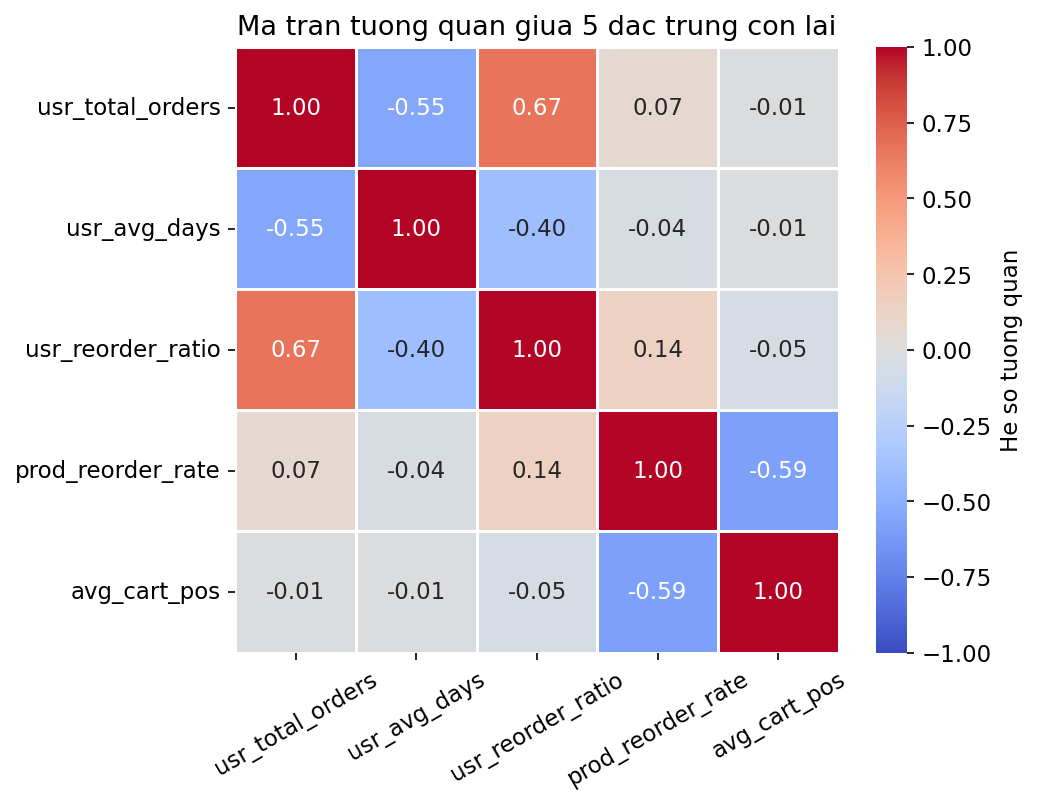

In [28]:
corr_matrix = df_feat[FEATURES].corr()

short = [FEAT_LABELS[f] for f in FEATURES]
corr_display = corr_matrix.copy()
corr_display.index   = short
corr_display.columns = short

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_display, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "He so tuong quan"})
ax.set_title("Ma tran tuong quan giua 5 dac trung con lai", fontsize=13)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("output/charts/C0c_feature_correlation_5.png", dpi=150, bbox_inches="tight")
plt.show()

## Chuẩn bị dữ liệu tra cứu cho demo <a id="demo-setup"></a>

Dựng sẵn ba bảng tra cứu dùng chung cho hai demo:
- `CLUSTER_NAMES` — tên nhóm khách hàng gán cho từng cluster (căn cứ hồ sơ RFM trung bình).
- `user_feat` — đặc trưng phía user (lấy trực tiếp từ `df_feat`, mỗi user một dòng).
- `prod_catalog` — bảng ~20 sản phẩm phổ biến trải theo department (tên dễ đọc) kèm đặc trưng phía product, đọc từ SQL Server.

In [29]:
# ─── A. Gán tên nhóm cho từng cluster dựa trên hồ sơ RFM trung bình ───
# recency THAP + frequency/monetary CAO  -> nhom cang tot
_prof = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean()
# diem tong hop: frequency + monetary cang cao, recency cang thap -> diem cang cao
_rank = (_prof["frequency"].rank() + _prof["monetary"].rank()
         + (len(_prof) + 1 - _prof["recency"].rank()))
_order = _rank.sort_values(ascending=False).index.tolist()   # tot -> kem

_NAME_BY_RANK = [
    "Khach hang VIP",
    "Khach hang trung thanh",
    "Khach hang tiem nang",
    "Khach hang co nguy co roi bo",
]
CLUSTER_NAMES = {cl: _NAME_BY_RANK[i] for i, cl in enumerate(_order)}

print("Ten nhom gan cho tung cluster:")
for cl in sorted(CLUSTER_NAMES):
    p = _prof.loc[cl]
    print(f"  Cluster {cl}: {CLUSTER_NAMES[cl]:<32} "
          f"| R={p['recency']:.1f}  F={p['frequency']:.1f}  M={p['monetary']:.1f}")

# ─── B. Bang dac trung phia user (moi user 1 dong) ───
USER_COLS = ["user_total_orders", "user_avg_days_between_orders", "user_reorder_ratio"]
user_feat = (df_feat.groupby("user_id")[USER_COLS].first())
print(f"\nBang user_feat: {len(user_feat):,} user")

# ─── C. Catalog san pham pho bien trai theo department (doc tu SQL) ───
CATALOG_SQL = """
WITH prod_pop AS (
    SELECT
        p.product_id,
        p.product_name,
        d.department,
        COUNT(*)                                        AS total_orders,
        ROW_NUMBER() OVER (PARTITION BY d.department
                           ORDER BY COUNT(*) DESC)       AS rn
    FROM order_products_prior opp
    JOIN products    p ON opp.product_id = p.product_id
    JOIN departments d ON p.department_id = d.department_id
    GROUP BY p.product_id, p.product_name, d.department
)
SELECT TOP 20 product_id, product_name, department, total_orders
FROM prod_pop
WHERE rn = 1
ORDER BY total_orders DESC;
"""
prod_catalog = pd.read_sql(CATALOG_SQL, engine).set_index("product_id")

# Gan dac trung phia product cho catalog: lay tu df_feat (trung binh toan he thong)
PROD_COLS = ["product_reorder_rate", "avg_add_to_cart_position"]
_prod_feat = df_feat.groupby("product_id")[PROD_COLS].first()
prod_catalog = prod_catalog.join(_prod_feat, how="left")
# San pham nao khong co trong feature_table -> dien trung binh chung de khong loi
prod_catalog[PROD_COLS] = prod_catalog[PROD_COLS].fillna(df_feat[PROD_COLS].mean())

print(f"\nCatalog san pham demo: {len(prod_catalog)} san pham")
display(prod_catalog[["product_name", "department",
                      "product_reorder_rate", "avg_add_to_cart_position"]])


Ten nhom gan cho tung cluster:
  Cluster 0: Khach hang trung thanh           | R=9.4  F=35.9  M=356.7
  Cluster 1: Khach hang tiem nang             | R=8.9  F=11.0  M=88.7
  Cluster 2: Khach hang VIP                   | R=5.6  F=69.8  M=840.4
  Cluster 3: Khach hang co nguy co roi bo     | R=28.1  F=9.5  M=79.6

Bang user_feat: 131,209 user

Catalog san pham demo: 20 san pham


,product_name,department,product_reorder_rate,avg_add_to_cart_position
product_id,,,,
24852,Banana,produce,0.8435,4.894129
27845,Organic Whole Milk,dairy eggs,0.8304,5.434749
44632,Sparkling Water Grapefruit,beverages,0.7711,6.222702
30489,Original Hummus,deli,0.7248,8.413271
5077,100% Whole Wheat Bread,bakery,0.7372,7.045218
9076,Blueberries,frozen,0.5826,8.316931
25890,Boneless Skinless Chicken Breasts,meat seafood,0.6620,7.513912
31506,Extra Virgin Olive Oil,pantry,0.4766,9.010148
27156,Organic Black Beans,canned goods,0.5882,10.030947


---
## Demo A — Phân khúc khách hàng (K-Means) <a id="demo-a"></a>

Nhập 3 chỉ số RFM của một khách hàng, hệ thống dùng đúng `scaler` và `km_final` đã huấn luyện để gán khách vào 1 trong 4 nhóm.

Để chứng minh việc gán nhóm là đúng, phần kết quả in ra khoảng cách từ điểm khách hàng tới tâm (centroid) của cả 4 nhóm (đơn vị đã chuẩn hóa) — nhóm được gán là nhóm có khoảng cách nhỏ nhất, các nhóm còn lại đều xa hơn rõ rệt. Kèm theo là khoảng giá trị RFM thực tế của nhóm để thấy khách rơi đúng vào vùng của nhóm đó.

**Ý nghĩa 3 chỉ số:** Recency = số ngày kể từ lần mua gần nhất (thấp là mới mua), Frequency = tổng số đơn đã đặt, Monetary = tổng số sản phẩm đã mua.

In [30]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

# Khoang gia tri thuc te tung nhom (min-max) -> lam bang chung "roi dung vung"
_rng = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].agg(["min", "max"])

# Gia tri mac dinh cho o nhap: lay trung vi toan bo cho de nhin
_med = rfm[["recency", "frequency", "monetary"]].median()

in_recency   = widgets.FloatText(value=float(_med["recency"]),   description="Recency:")
in_frequency = widgets.FloatText(value=float(_med["frequency"]), description="Frequency:")
in_monetary  = widgets.FloatText(value=float(_med["monetary"]),  description="Monetary:")
btn_a  = widgets.Button(description="Phan nhom khach hang", button_style="primary")
out_a  = widgets.Output()

def phan_nhom(_):
    with out_a:
        clear_output()
        x = pd.DataFrame([[in_recency.value, in_frequency.value, in_monetary.value]],
                         columns=["recency", "frequency", "monetary"])
        x_scaled = scaler.transform(x)                      # dung dung scaler da fit
        x = x.values                                        # dung tiep duoi dang mang
        cluster  = int(km_final.predict(x_scaled)[0])
        name     = CLUSTER_NAMES[cluster]

        # Khoang cach toi 4 centroid (khong gian chuan hoa)
        dists = np.linalg.norm(km_final.cluster_centers_ - x_scaled, axis=1)
        order = np.argsort(dists)                            # gan -> xa

        print(f"Khach hang duoc phan vao: CLUSTER {cluster} — {name}")
        print(f"  (Input: R={x[0,0]:.1f}, F={x[0,1]:.1f}, M={x[0,2]:.1f})")
        print()
        print("Bang chung — khoang cach toi tam 4 nhom (don vi da chuan hoa):")
        print(f"  {'Cluster':<9}{'Ten nhom':<32}{'Khoang cach':>12}   Ket luan")
        print("  " + "-" * 72)
        for rank, cl in enumerate(order):
            tag = "  <== GAN VAO DAY (gan nhat)" if rank == 0 else \
                  f"  xa hon {dists[cl]/dists[order[0]]:.1f} lan"
            print(f"  {cl:<9}{CLUSTER_NAMES[cl]:<32}{dists[cl]:>12.3f}{tag}")

        print()
        print(f"Vi sao dung nhom '{name}' — khach roi vao vung gia tri cua nhom:")
        r = _rng.loc[cluster]
        for col in ["recency", "frequency", "monetary"]:
            lo, hi = r[(col, "min")], r[(col, "max")]
            v = x[0, ["recency", "frequency", "monetary"].index(col)]
            inside = "trong khoang" if lo <= v <= hi else "ngoai khoang (gan bien)"
            print(f"  {col:<11}: input={v:>8.1f}  | vung nhom [{lo:.1f} .. {hi:.1f}]  -> {inside}")

btn_a.on_click(phan_nhom)
display(widgets.VBox([in_recency, in_frequency, in_monetary, btn_a, out_a]))


---
## Demo B — Gợi ý sản phẩm khả năng mua lại (XGBoost) <a id="demo-b"></a>

Chọn 1 khách hàng (user_id thật trong dữ liệu) và tick 3-5 sản phẩm đưa vào giỏ. Hệ thống ghép đặc trưng phía user (của khách đã chọn) với đặc trưng phía product (của từng sản phẩm) thành đúng 5 đặc trưng mà `xgb` đã học, rồi chấm điểm khả năng mua lại cho từng sản phẩm và trả về **top 3 cao nhất, sắp giảm dần theo tỷ lệ**.

**Lưu ý:** dataset Instacart không có dữ liệu số lượng, nên "giỏ hàng" ở đây là tập sản phẩm được chọn; mô hình xét từng sản phẩm độc lập chứ không xét số lượng.

In [33]:
# Chon user: lay mau 300 user co nhieu don nhat cho drop-down goi (de co lich su ro rang)
_top_users = (user_feat.sort_values("user_total_orders", ascending=False)
                        .head(300).index.tolist())
user_dd = widgets.Dropdown(
    options=[(f"user {u} (tong {int(user_feat.loc[u,'user_total_orders'])} don, "
              f"reorder ratio {user_feat.loc[u,'user_reorder_ratio']:.2f})", u)
             for u in _top_users],
    description="Khach hang:",
    layout=widgets.Layout(width="480px"),
    style={"description_width": "90px"},
)

# Checkbox san pham tu catalog
prod_boxes = [
    widgets.Checkbox(value=False,
                     description=f"{row.product_name}  ({row.department})",
                     indent=False,
                     layout=widgets.Layout(width="440px"))
    for pid, row in prod_catalog.iterrows()
]
_pid_by_box = {id(b): pid for b, pid in zip(prod_boxes, prod_catalog.index)}

btn_b = widgets.Button(description="Goi y san pham mua lai", button_style="primary")
out_b = widgets.Output()

# Thu tu cot dac trung PHAI khop dung thu tu FEATURES da train
def _build_row(uid, pid):
    u = user_feat.loc[uid]
    p = prod_catalog.loc[pid]
    src = {**u.to_dict(), **p.to_dict()}
    return [src[f] for f in FEATURES]

def goi_y(_):
    with out_b:
        clear_output()
        uid = user_dd.value
        chosen = [_pid_by_box[id(b)] for b in prod_boxes if b.value]

        if not (3 <= len(chosen) <= 5):
            print(f"Vui long chon tu 3 den 5 san pham (dang chon {len(chosen)}).")
            return

        candidates = [pid for pid in prod_catalog.index if pid not in chosen]
        X_cand = pd.DataFrame([_build_row(uid, pid) for pid in candidates],
                              columns=FEATURES, index=candidates)
        probs = xgb.predict_proba(X_cand)[:, 1]

        res = (pd.DataFrame({
                    "product_name": prod_catalog.loc[candidates, "product_name"].values,
                    "department":   prod_catalog.loc[candidates, "department"].values,
                    "ty_le_mua_lai": probs,
                    "ty_le_naive":   prod_catalog.loc[candidates, "product_reorder_rate"].values})
               .sort_values("ty_le_mua_lai", ascending=False)
               .reset_index(drop=True))

        top3_model = set(res.head(3)["product_name"])
        top3_naive = set(res.sort_values("ty_le_naive", ascending=False)
                          .head(3)["product_name"])
        trung = len(top3_model & top3_naive)

        print(f"Khach hang: user {uid}  "
              f"(reorder ratio lich su = {user_feat.loc[uid,'user_reorder_ratio']:.2f})")
        gio_hang = ", ".join(prod_catalog.loc[chosen, "product_name"])
        print(f"Gio hang hien tai ({len(chosen)} san pham): {gio_hang}")
        print(f"\nTop 3 goi y mua them theo MODEL (khong trung gio hang):\n")
        top3 = res.head(3)
        for i, r in top3.iterrows():
            bar = "#" * int(round(r["ty_le_mua_lai"] * 20))
            print(f"  {i+1}. {r['product_name']:<26} ({r['department']:<14}) "
                  f"model={r['ty_le_mua_lai']*100:5.1f}%  naive={r['ty_le_naive']*100:5.1f}%  {bar}")

        print(f"\nSo sanh voi baseline naive (chi xep theo product_reorder_rate, khong dung model):")
        print(f"  Trung {trung}/3 san pham o top 3 giua model va naive.")
        if trung == 3:
            print("  -> Voi khach hang nay, model gan nhu tuong duong xep theo do pho bien san pham.")
        else:
            print("  -> Model dieu chinh thu tu khac voi chi xep theo do pho bien, do anh huong tu lich su rieng cua khach hang.")

        print("\nDay du cac san pham con lai (sap giam dan theo model):")
        _show = res.copy()
        _show["ty_le_mua_lai"] = (_show["ty_le_mua_lai"] * 100).round(1).astype(str) + "%"
        _show["ty_le_naive"]   = (_show["ty_le_naive"]   * 100).round(1).astype(str) + "%"
        display(_show)

btn_b.on_click(goi_y)

display(widgets.VBox([
    user_dd,
    widgets.HTML("<b>Chon 3-5 san pham dua vao gio:</b>"),
    widgets.VBox(prod_boxes),
    btn_b,
    out_b,
]))


---
## Demo C — So sánh 2 khách hàng trên cùng danh sách sản phẩm <a id="demo-c"></a>

Chọn 2 khách hàng khác nhau, chấm điểm khả năng mua lại của cả hai người trên đúng cùng bộ sản phẩm trong catalog. Mặc định chọn sẵn 1 người có reorder ratio cao nhất và 1 người thấp nhất trong nhóm mẫu. Nếu model chỉ lặp lại độ phổ biến sản phẩm, xác suất giữa 2 người sẽ gần như giống hệt nhau; chênh lệch càng lớn càng chứng minh model có cá nhân hoá thật.

In [35]:
_by_loyalty = user_feat.loc[_top_users].sort_values("user_reorder_ratio")
default_low_user, default_high_user = _by_loyalty.index[0], _by_loyalty.index[-1]

user_dd_a = widgets.Dropdown(
    options=[(f"user {u} (reorder ratio {user_feat.loc[u,'user_reorder_ratio']:.2f})", u)
             for u in _top_users],
    value=default_high_user, description="Khach hang A:",
    layout=widgets.Layout(width="480px"), style={"description_width": "100px"},
)
user_dd_b = widgets.Dropdown(
    options=[(f"user {u} (reorder ratio {user_feat.loc[u,'user_reorder_ratio']:.2f})", u)
             for u in _top_users],
    value=default_low_user, description="Khach hang B:",
    layout=widgets.Layout(width="480px"), style={"description_width": "100px"},
)
btn_c = widgets.Button(description="So sanh 2 khach hang", button_style="primary")
out_c = widgets.Output()

def so_sanh(_):
    with out_c:
        clear_output()
        uid_a, uid_b = user_dd_a.value, user_dd_b.value
        if uid_a == uid_b:
            print("Vui long chon 2 khach hang khac nhau.")
            return

        prods = prod_catalog.index.tolist()
        Xa = pd.DataFrame([_build_row(uid_a, pid) for pid in prods], columns=FEATURES, index=prods)
        Xb = pd.DataFrame([_build_row(uid_b, pid) for pid in prods], columns=FEATURES, index=prods)
        pa = xgb.predict_proba(Xa)[:, 1]
        pb = xgb.predict_proba(Xb)[:, 1]

        cmp = pd.DataFrame({
            "product_name": prod_catalog.loc[prods, "product_name"].values,
            "user_A": pa,
            "user_B": pb,
        })
        cmp["chenh_lech"] = (cmp["user_A"] - cmp["user_B"]).abs()
        cmp = cmp.sort_values("chenh_lech", ascending=False).reset_index(drop=True)

        print(f"User A = {uid_a}  (reorder ratio = {user_feat.loc[uid_a,'user_reorder_ratio']:.2f}, "
              f"tong don = {int(user_feat.loc[uid_a,'user_total_orders'])})")
        print(f"User B = {uid_b}  (reorder ratio = {user_feat.loc[uid_b,'user_reorder_ratio']:.2f}, "
              f"tong don = {int(user_feat.loc[uid_b,'user_total_orders'])})")
        print(f"Cung {len(prods)} san pham, chenh lech xac suat trung binh giua 2 nguoi: "
              f"{cmp['chenh_lech'].mean()*100:.1f} diem %")
        print(f"Chenh lech lon nhat: {cmp['chenh_lech'].max()*100:.1f} diem % "
              f"(san pham: {cmp.iloc[0]['product_name']})\n")

        _show = cmp.copy()
        for col in ["user_A", "user_B", "chenh_lech"]:
            _show[col] = (_show[col] * 100).round(1).astype(str) + "%"
        display(_show)

btn_c.on_click(so_sanh)
display(widgets.VBox([user_dd_a, user_dd_b, btn_c, out_c]))

In [36]:
import joblib, json, os

EXPORT_DIR = "output/streamlit_data"
os.makedirs(EXPORT_DIR, exist_ok=True)

joblib.dump(scaler, f"{EXPORT_DIR}/scaler.joblib")
joblib.dump(km_final, f"{EXPORT_DIR}/kmeans.joblib")
joblib.dump(xgb, f"{EXPORT_DIR}/xgb_model.joblib")

with open(f"{EXPORT_DIR}/cluster_names.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in CLUSTER_NAMES.items()}, f, ensure_ascii=False, indent=2)

with open(f"{EXPORT_DIR}/features.json", "w", encoding="utf-8") as f:
    json.dump(FEATURES, f, indent=2)

_rng_flat = _rng.copy()
_rng_flat.columns = ["_".join(c) for c in _rng_flat.columns]
_rng_flat.to_csv(f"{EXPORT_DIR}/cluster_ranges.csv")

user_feat.loc[_top_users].to_csv(f"{EXPORT_DIR}/user_feat_sample.csv")
prod_catalog.to_csv(f"{EXPORT_DIR}/prod_catalog.csv")

print(f"Da luu vao {EXPORT_DIR}/")
for fn in sorted(os.listdir(EXPORT_DIR)):
    print(" ", fn)

Da luu vao output/streamlit_data/
  cluster_names.json
  cluster_ranges.csv
  features.json
  kmeans.joblib
  prod_catalog.csv
  scaler.joblib
  user_feat_sample.csv
  xgb_model.joblib


---
## Python ML Summary <a id="c-summary"></a>

Python ML đã hoàn thành quy trình kiểm định đặc trưng, xây dựng và đánh giá mô hình học máy dự đoán khả năng đặt lại sản phẩm.

| Bước | Nội dung | Kết quả |
|---|---|---|
| I | Phân khúc khách hàng — K-Means trên chỉ số RFM | 4 cụm khách hàng, xuất `rfm_clustered.csv` |
| II | Kiểm định leakage + đa cộng tuyến trên 6 đặc trưng ứng viên | Loại `user_product_times_bought`, chốt 5 đặc trưng chính thức |
| III | Kiểm tra cân bằng nhãn | Tỷ lệ ~59/41%, lệch nhẹ |
| IV | Chia train/test 80/20 (stratify) | Giữ đúng tỷ lệ nhãn ở cả 2 tập |
| V | Logistic Regression (Pipeline + GridSearchCV) | Baseline, tìm `C` tối ưu |
| VI | XGBoost + GridSearchCV | Mô hình chính |
| VII | Learning Curve | Kiểm tra overfitting |
| VIII | Confusion Matrix + Classification Report | So sánh lỗi FP/FN |
| IX | Bảng dự đoán mẫu trên tập Test | Minh họa trực quan dự đoán |
| X | ROC Curve | So sánh AUC tổng thể |
| XI | Bootstrap AUC | Kiểm định ý nghĩa thống kê chênh lệch AUC |
| XII | Precision-Recall Curve + Threshold Analysis | Tìm threshold tối ưu F1 |
| XIII | Feature Importance (XGBoost) + Coefficients chuẩn hóa (Logistic Regression) | Xác định đặc trưng ảnh hưởng nhiều nhất |
| XIV | Xuất `model_results.csv` + `feature_audit.csv` | Đầu vào Power BI + minh chứng kiểm định đặc trưng |

**Output files:**

| File | Mục đích |
|---|---|
| `output/charts/B6a_elbow.png` | Minh họa cách chọn k cho K-Means |
| `output/charts/B6b_cluster_heatmap.png` | Hồ sơ trung bình từng cụm (Cluster Profile) |
| `output/rfm_clustered.csv` | Power BI — Dashboard phân khúc khách hàng |
| `output/charts/C0a_leakage_correlation.png` | Minh chứng kiểm tra leakage |
| `output/charts/C0b_feature_correlation_matrix.png` | Minh chứng kiểm tra đa cộng tuyến |
| `output/charts/C1_label_balance.png` | Minh chứng cân bằng nhãn |
| `output/charts/C4b_learning_curve.png` | Minh chứng kiểm tra overfitting |
| `output/charts/C5_confusion_matrix.png` | Minh chứng đánh giá mô hình |
| `output/charts/C6_roc_curve.png` | Minh chứng so sánh ROC |
| `output/charts/C6b_auc_bootstrap.png` | Minh chứng ý nghĩa thống kê chênh lệch AUC |
| `output/charts/C7a_precision_recall_curve.png`, `C7b_threshold_analysis.png` | Minh chứng Precision-Recall & threshold |
| `output/charts/C8a_feature_importance.png`, `C8b_lr_coefficients.png` | Minh chứng feature importance |
| `output/model_results.csv` | Power BI — Trang kết quả mô hình dự đoán |
| `output/feature_audit.csv` | Minh chứng kiểm định đặc trưng — chèn vào Phần III.5 báo cáo |
| `output/best_threshold.txt` | Tham khảo khi triển khai gợi ý sản phẩm |

**Việc cần làm khi chạy thật:**
1. Điền các đoạn "Phân tích" còn để trống bằng số liệu thực tế.
2. Chèn bảng `audit_table` (bước Chốt danh sách đặc trưng) vào Phần III.5 báo cáo như minh chứng kiểm định đặc trưng trước khi modeling.
3. Nếu GridSearchCV trên XGBoost quá lâu, giảm `param_grid_xgb` hoặc đổi sang `RandomizedSearchCV`.

---
*Notebook trước: **Python EDA — Exploratory Data Analysis***

---
## Python ML Summary <a id="c-summary"></a>

Python ML đã hoàn thành quy trình kiểm định đặc trưng, xây dựng và đánh giá mô hình học máy dự đoán khả năng đặt lại sản phẩm.

| Bước | Nội dung | Kết quả |
|---|---|---|
| I | Phân khúc khách hàng — K-Means trên chỉ số RFM | 4 cụm khách hàng, xuất `rfm_clustered.csv` |
| II | Kiểm định leakage + đa cộng tuyến trên 6 đặc trưng ứng viên | Loại `user_product_times_bought`, chốt 5 đặc trưng chính thức |
| III | Kiểm tra cân bằng nhãn | Tỷ lệ ~59/41%, lệch nhẹ |
| IV | Chia train/test 80/20 (stratify) | Giữ đúng tỷ lệ nhãn ở cả 2 tập |
| V | Logistic Regression (Pipeline + GridSearchCV) | Baseline, tìm `C` tối ưu |
| VI | XGBoost + GridSearchCV | Mô hình chính |
| VII | Learning Curve | Kiểm tra overfitting |
| VIII | Confusion Matrix + Classification Report | So sánh lỗi FP/FN |
| IX | Bảng dự đoán mẫu trên tập Test | Minh họa trực quan dự đoán |
| X | ROC Curve | So sánh AUC tổng thể |
| XI | Bootstrap AUC | Kiểm định ý nghĩa thống kê chênh lệch AUC |
| XII | Precision-Recall Curve + Threshold Analysis | Tìm threshold tối ưu F1 |
| XIII | Feature Importance (XGBoost) + Coefficients chuẩn hóa (Logistic Regression) | Xác định đặc trưng ảnh hưởng nhiều nhất |
| XIV | Xuất `model_results.csv` + `feature_audit.csv` | Đầu vào Power BI + minh chứng kiểm định đặc trưng |

**Output files:**

| File | Mục đích |
|---|---|
| `output/charts/B6a_elbow.png` | Minh họa cách chọn k cho K-Means |
| `output/charts/B6b_cluster_heatmap.png` | Hồ sơ trung bình từng cụm (Cluster Profile) |
| `output/rfm_clustered.csv` | Power BI — Dashboard phân khúc khách hàng |
| `output/charts/C0a_leakage_correlation.png` | Minh chứng kiểm tra leakage |
| `output/charts/C0b_feature_correlation_matrix.png` | Minh chứng kiểm tra đa cộng tuyến |
| `output/charts/C1_label_balance.png` | Minh chứng cân bằng nhãn |
| `output/charts/C4b_learning_curve.png` | Minh chứng kiểm tra overfitting |
| `output/charts/C5_confusion_matrix.png` | Minh chứng đánh giá mô hình |
| `output/charts/C6_roc_curve.png` | Minh chứng so sánh ROC |
| `output/charts/C6b_auc_bootstrap.png` | Minh chứng ý nghĩa thống kê chênh lệch AUC |
| `output/charts/C7a_precision_recall_curve.png`, `C7b_threshold_analysis.png` | Minh chứng Precision-Recall & threshold |
| `output/charts/C8a_feature_importance.png`, `C8b_lr_coefficients.png` | Minh chứng feature importance |
| `output/model_results.csv` | Power BI — Trang kết quả mô hình dự đoán |
| `output/feature_audit.csv` | Minh chứng kiểm định đặc trưng — chèn vào Phần III.5 báo cáo |
| `output/best_threshold.txt` | Tham khảo khi triển khai gợi ý sản phẩm |

**Việc cần làm khi chạy thật:**
1. Điền các đoạn "Phân tích" còn để trống bằng số liệu thực tế.
2. Chèn bảng `audit_table` (bước Chốt danh sách đặc trưng) vào Phần III.5 báo cáo như minh chứng kiểm định đặc trưng trước khi modeling.
3. Nếu GridSearchCV trên XGBoost quá lâu, giảm `param_grid_xgb` hoặc đổi sang `RandomizedSearchCV`.

---
*Notebook trước: **Python EDA — Exploratory Data Analysis***